# Tuned 1–24 Hour Smart-City Traffic Forecasting
## PatchTST vs LightGBM, XGBoost, CatBoost, baselines, and ensembles

This notebook builds an **auditable, leakage-safe forecasting benchmark** for citywide hourly `vehicle_count`. It compares:

- `LGBMRegressor`
- `XGBRegressor`
- `CatBoostRegressor`
- `PatchTST` (transformer)
- 24-hour and 168-hour seasonal-naïve baselines
- mean, median, inverse-error, and non-negative stacked ensembles

Every requested model is tuned with Optuna. Tuning uses historical windows that end **before** the four final evaluation windows. The final leaderboard therefore measures generalization rather than how well Optuna memorized the test period.

**Default analytical target:** total `vehicle_count` across all 100 intersections. Change `TARGET` to `"average_speed"` to model mean network speed.

> Operational guardrail: this is a simulated dataset covering roughly three months. Treat results as a reproducible modeling study, not evidence that one algorithm will remain best in production.

## Notebook map

1. Setup and data validation
2. Series structure and baselines
3. Nested time-validation design
4. Transparent multi-horizon features
5. Optuna tuning for all four model families
6. Ensemble weights learned from inner out-of-fold predictions
7. Untouched outer-window evaluation
8. Advanced diagnostics and comprehensive visuals
9. Full-data refit and next-24-hour forecast
10. Conclusions, limitations, and production checklist

Primary documentation:

- LightGBM Python API: https://lightgbm.readthedocs.io/en/latest/Python-API.html
- XGBoost Python API: https://xgboost.readthedocs.io/en/stable/python/python_api.html
- CatBoost regression: https://catboost.ai/en/docs/concepts/python-reference_catboostregressor
- Optuna: https://optuna.readthedocs.io/
- PatchTST paper: https://arxiv.org/abs/2211.14730
- NeuralForecast PatchTST: https://nixtlaverse.nixtla.io/neuralforecast/models.patchtst.html

## 0. Environment setup

Install packages once if your environment does not already contain them:

```python
%pip install pandas numpy matplotlib seaborn scipy scikit-learn optuna         lightgbm xgboost catboost torch neuralforecast
```

**macOS note:** LightGBM and XGBoost require an OpenMP runtime. The standard fix is `brew install libomp`. This notebook was verified using the compatible `libomp.dylib` bundled with PyTorch by launching Jupyter with `DYLD_LIBRARY_PATH` set to PyTorch's library directory.

In [1]:
import os
import sys
import time
from pathlib import Path
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))
os.environ.setdefault("XDG_CACHE_HOME", str(Path.cwd() / ".cache"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sea
import matplotlib.pyplot as plt
import optuna
import torch

from IPython.display import display, Markdown
from scipy.optimize import nnls
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.graphics.tsaplots import plot_acf

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from neuralforecast.losses.pytorch import MAE

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sea.set_theme(style="whitegrid", context="notebook")
COLORS = ["#2563EB", "#0F766E", "#F59E0B", "#DC2626", "#7C3AED", "#0891B2", "#64748B", "#DB2777"]
plt.rcParams.update({"figure.figsize": (12, 6), "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})

print({
    "python": sys.version.split()[0], "optuna": optuna.__version__, "torch": torch.__version__,
    "accelerator": "MPS" if torch.backends.mps.is_available() else "CPU"
})

2026-09-02 13:05:35,443	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


2026-09-02 13:05:35,810	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


{'python': '3.12.13', 'optuna': '4.9.0', 'torch': '2.14.0', 'accelerator': 'CPU'}


## 1. Configuration and target construction

The code uses a modest Optuna budget so the entire notebook remains practical on CPU. Increase `N_TRIALS_TREE` and `N_TRIALS_PATCHTST` for a production experiment. The validation structure matters more than squeezing in many poorly controlled trials.

In [2]:
TARGET = "vehicle_count"          # Alternative: "average_speed"
AGGREGATION = {"vehicle_count": "sum", "average_speed": "mean"}
HORIZON = 24
OUTER_SPLITS = 4                   # Untouched final evaluation: 4 × 24 hours
INNER_SPLITS = 3                   # Optuna objective: 3 earlier × 24-hour windows
LAGS = list(range(1, 25)) + [48, 72, 168, 336]

N_TRIALS_TREE = 8                 # Per tree family; increase to 30–100+ for production
N_TRIALS_PATCHTST = 5             # Neural tuning is more expensive
PATCH_TUNE_STEPS = 60
PATCH_EVAL_STEPS = 200

MODEL_FAMILIES = ["LightGBM", "XGBoost", "CatBoost", "PatchTST"]
BASELINES = ["Naive_24h", "Naive_168h"]

DATA_CANDIDATES = [
    Path("work/smart_city_traffic_mobility.csv"),
    Path("/Users/khoatran3126/Downloads/smart_city_traffic_mobility.csv"),
    Path("smart_city_traffic_mobility.csv"), Path("../smart_city_traffic_mobility.csv"),
    Path("/content/smart_city_traffic_mobility.csv"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Update DATA_CANDIDATES so one entry points to smart_city_traffic_mobility.csv")
if TARGET not in AGGREGATION:
    raise ValueError(f"TARGET must be one of {list(AGGREGATION)}")

raw = pd.read_csv(DATA_PATH, usecols=["timestamp", "intersection_id", TARGET], parse_dates=["timestamp"])
series = (raw.groupby("timestamp", as_index=False)
             .agg(y=(TARGET, AGGREGATION[TARGET]))
             .rename(columns={"timestamp": "ds"})
             .sort_values("ds").reset_index(drop=True))
series["unique_id"] = f"citywide_{TARGET}"

print(f"Source: {DATA_PATH}")
print(f"Target: {TARGET} ({AGGREGATION[TARGET]} across intersections)")
print(f"Coverage: {series.ds.min()} to {series.ds.max()} | {len(series):,} hourly values")
display(series.head())

Source: /Users/khoatran3126/Downloads/smart_city_traffic_mobility.csv
Target: vehicle_count (sum across intersections)
Coverage: 2026-01-01 00:00:00 to 2026-03-26 23:00:00 | 2,040 hourly values


,ds,y,unique_id
0,2026-01-01 00:00:00,19370,citywide_vehicle_count
1,2026-01-01 01:00:00,19155,citywide_vehicle_count
2,2026-01-01 02:00:00,18974,citywide_vehicle_count
3,2026-01-01 03:00:00,18730,citywide_vehicle_count
4,2026-01-01 04:00:00,19014,citywide_vehicle_count


In [3]:
expected_clock = pd.date_range(series.ds.min(), series.ds.max(), freq="h")
integrity = pd.Series({
    "hourly_clock_complete": pd.DatetimeIndex(series.ds).equals(expected_clock),
    "timestamps_unique": series.ds.is_unique,
    "target_complete": series.y.notna().all(),
    "target_finite": np.isfinite(series.y).all(),
    "target_nonnegative": series.y.ge(0).all(),
    "enough_history": len(series) > max(LAGS) + (OUTER_SPLITS + INNER_SPLITS) * HORIZON,
}, name="passed")
display(integrity.to_frame())
assert integrity.all(), "Resolve failed integrity checks before modeling."

,passed
hourly_clock_complete,True
timestamps_unique,True
target_complete,True
target_finite,True
target_nonnegative,True
enough_history,True


## 2. Series structure and the bar that models must beat

Seasonal baselines are not ceremonial. Urban traffic commonly repeats by hour of day and day of week; a complex model must improve upon those patterns consistently enough to justify its operational cost.

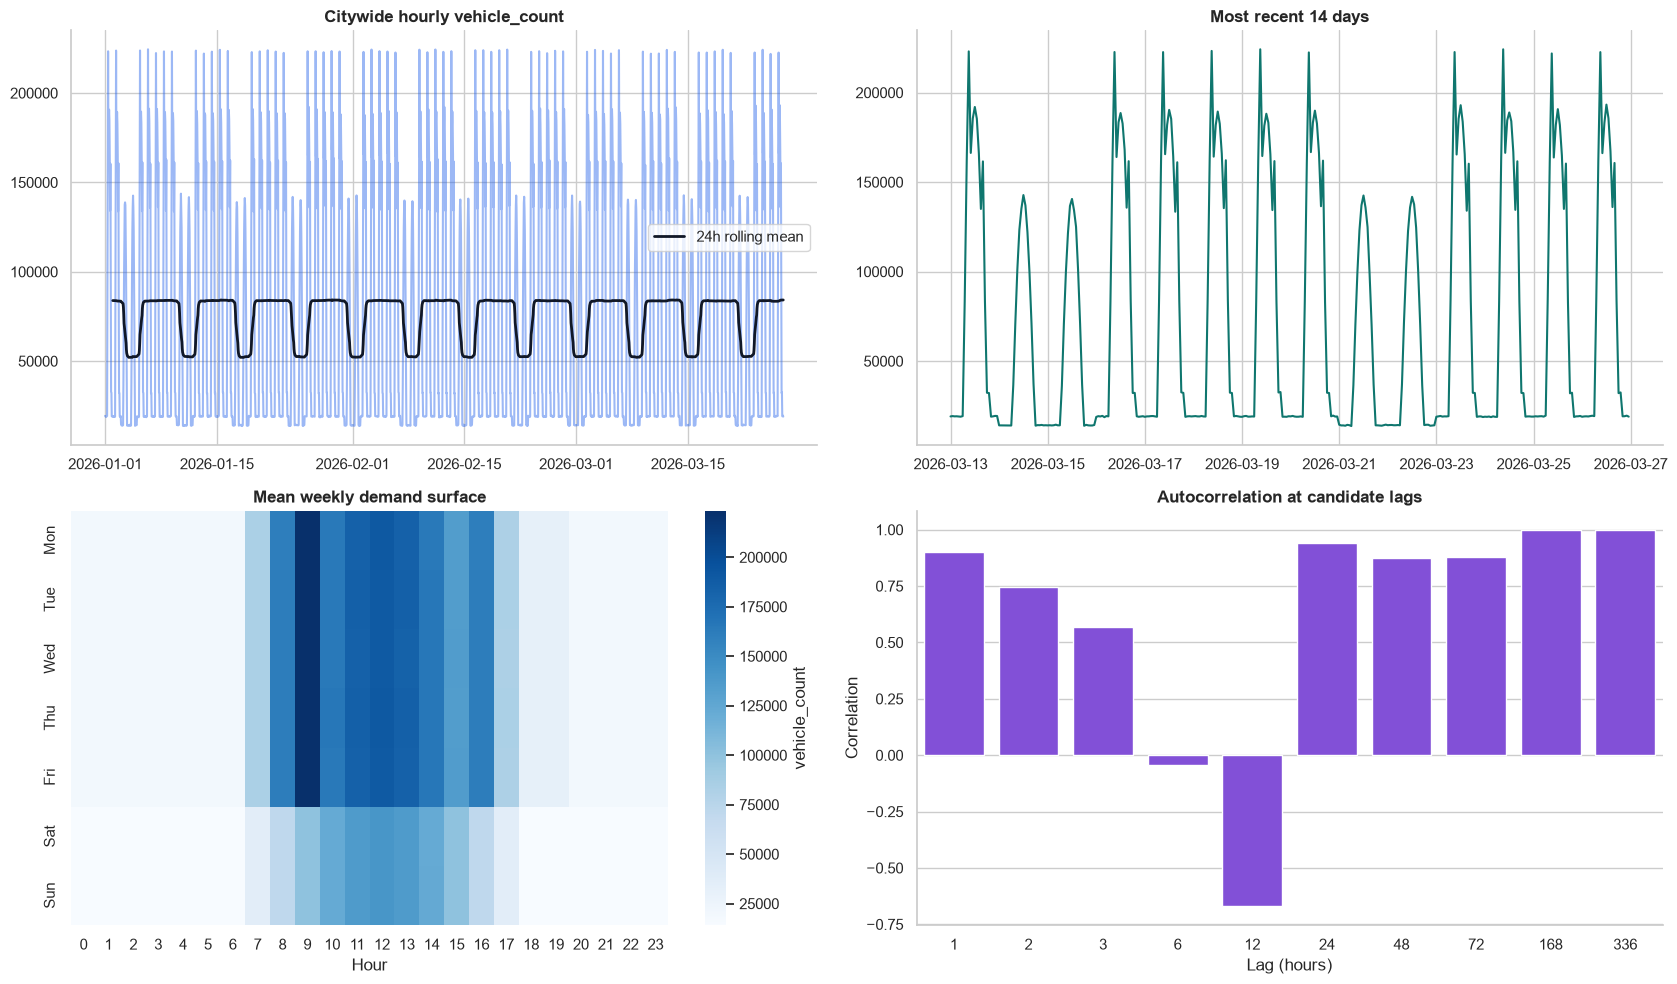

In [4]:
profile = series.assign(hour=series.ds.dt.hour, day_of_week=series.ds.dt.dayofweek)
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekly = profile.groupby(["day_of_week", "hour"]).y.mean().unstack()
weekly.index = day_names

fig, axes = plt.subplots(2, 2, figsize=(17, 10))
axes[0, 0].plot(series.ds, series.y, color=COLORS[0], alpha=.45)
axes[0, 0].plot(series.ds, series.y.rolling(24).mean(), color="#111827", linewidth=2, label="24h rolling mean")
axes[0, 0].set_title(f"Citywide hourly {TARGET}"); axes[0, 0].legend()
recent = series.tail(24 * 14)
axes[0, 1].plot(recent.ds, recent.y, color=COLORS[1])
axes[0, 1].set_title("Most recent 14 days")
sea.heatmap(weekly, cmap="Blues", ax=axes[1, 0], cbar_kws={"label": TARGET})
axes[1, 0].set_title("Mean weekly demand surface"); axes[1, 0].set_xlabel("Hour"); axes[1, 0].set_ylabel("")
ac_lags = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]
sea.barplot(x=ac_lags, y=[series.y.autocorr(lag=x) for x in ac_lags], ax=axes[1, 1], color=COLORS[4])
axes[1, 1].set_title("Autocorrelation at candidate lags"); axes[1, 1].set_xlabel("Lag (hours)"); axes[1, 1].set_ylabel("Correlation")
plt.tight_layout(); plt.show()

## 3. Nested time-validation design

The timeline is split into two layers:

- **Inner rolling windows:** Optuna chooses hyperparameters and ensemble weights here.
- **Outer rolling windows:** held back until all choices are frozen; these produce the reported leaderboard.

Both layers use expanding training histories and non-overlapping 24-hour test blocks. This is a practical nested backtest: not every outer fold reruns Optuna, which keeps runtime manageable, but no final outer target is exposed during tuning.

In [5]:
values = series.y.to_numpy(dtype=float)
dates = series.ds.reset_index(drop=True)

outer_splitter = TimeSeriesSplit(n_splits=OUTER_SPLITS, test_size=HORIZON)
outer_indices = list(outer_splitter.split(series))
first_outer_origin = int(outer_indices[0][1][0])

development = series.iloc[:first_outer_origin]
inner_splitter = TimeSeriesSplit(n_splits=INNER_SPLITS, test_size=HORIZON)
inner_indices = list(inner_splitter.split(development))

split_rows = []
for layer, split_list in [("Inner / tuning", inner_indices), ("Outer / final evaluation", outer_indices)]:
    for fold, (train_idx, test_idx) in enumerate(split_list, start=1):
        split_rows.append({
            "layer": layer, "fold": fold, "train_start": dates.iloc[train_idx[0]],
            "train_end": dates.iloc[train_idx[-1]], "train_rows": len(train_idx),
            "test_start": dates.iloc[test_idx[0]], "test_end": dates.iloc[test_idx[-1]],
            "test_rows": len(test_idx),
        })
split_table = pd.DataFrame(split_rows)
display(split_table)

,layer,fold,train_start,train_end,train_rows,test_start,test_end,test_rows
0,Inner / tuning,1,2026-01-01,2026-03-19 23:00:00,1872,2026-03-20,2026-03-20 23:00:00,24
1,Inner / tuning,2,2026-01-01,2026-03-20 23:00:00,1896,2026-03-21,2026-03-21 23:00:00,24
2,Inner / tuning,3,2026-01-01,2026-03-21 23:00:00,1920,2026-03-22,2026-03-22 23:00:00,24
3,Outer / final evaluation,1,2026-01-01,2026-03-22 23:00:00,1944,2026-03-23,2026-03-23 23:00:00,24
4,Outer / final evaluation,2,2026-01-01,2026-03-23 23:00:00,1968,2026-03-24,2026-03-24 23:00:00,24
5,Outer / final evaluation,3,2026-01-01,2026-03-24 23:00:00,1992,2026-03-25,2026-03-25 23:00:00,24
6,Outer / final evaluation,4,2026-01-01,2026-03-25 23:00:00,2016,2026-03-26,2026-03-26 23:00:00,24


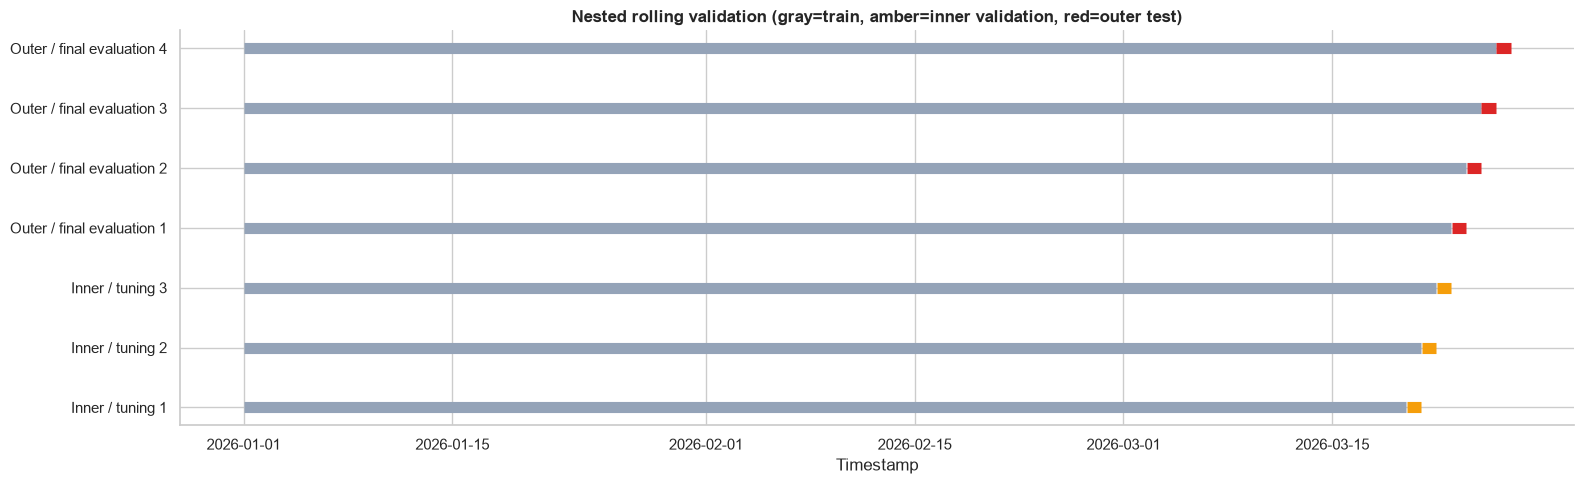

In [6]:
fig, ax = plt.subplots(figsize=(16, 5))
y_pos = 0
labels = []
for row in split_table.itertuples():
    labels.append(f"{row.layer} {row.fold}")
    ax.plot([row.train_start, row.train_end], [y_pos, y_pos], color="#94A3B8", linewidth=8, solid_capstyle="butt")
    test_color = COLORS[2] if row.layer.startswith("Inner") else COLORS[3]
    ax.plot([row.test_start, row.test_end], [y_pos, y_pos], color=test_color, linewidth=8, solid_capstyle="butt")
    y_pos += 1
ax.set_yticks(range(len(labels)), labels)
ax.set_title("Nested rolling validation (gray=train, amber=inner validation, red=outer test)")
ax.set_xlabel("Timestamp")
plt.tight_layout(); plt.show()

## 4. Readable direct multi-horizon feature engineering

One training row represents one forecast origin and one horizon. The model sees:

- lagged target values available at the origin;
- the requested horizon (1–24);
- cyclical hour/day fields for the forecasted timestamp;
- weekend status, which is known in advance.

The three tree models share the exact same design matrix. PatchTST uses the raw ordered series, because its architecture learns representations from patched historical windows.

In [7]:
def calendar_features(timestamp):
    '''Return only calendar information known before the forecast is made.'''
    hour, dow = timestamp.hour, timestamp.dayofweek
    return {
        "hour_sin": np.sin(2 * np.pi * hour / 24),
        "hour_cos": np.cos(2 * np.pi * hour / 24),
        "dow_sin": np.sin(2 * np.pi * dow / 7),
        "dow_cos": np.cos(2 * np.pi * dow / 7),
        "is_weekend": int(dow >= 5),
    }

def feature_row(values, dates, origin, horizon, lags=LAGS):
    '''Create one direct-forecast feature row using data available at origin.'''
    row = {f"lag_{lag}": values[origin - lag] for lag in lags}
    row.update(calendar_features(dates.iloc[origin + horizon - 1]))
    row["horizon"] = horizon
    return row

def stacked_training_frame(values, dates, train_end, lags=LAGS, horizon=HORIZON):
    '''Build all horizons while guaranteeing every target is before train_end.'''
    rows, targets = [], []
    for h in range(1, horizon + 1):
        for origin in range(max(lags), train_end - h + 1):
            rows.append(feature_row(values, dates, origin, h, lags))
            targets.append(values[origin + h - 1])
    return pd.DataFrame(rows), np.asarray(targets)

def forecast_frame(values, dates, origin, horizon=HORIZON):
    '''Build the 24 feature rows known at a single forecast origin.'''
    return pd.DataFrame([feature_row(values, dates, origin, h) for h in range(1, horizon + 1)])

all_origins = sorted({int(x[1][0]) for x in inner_indices + outer_indices})
training_cache = {}
for origin in all_origins:
    training_cache[origin] = stacked_training_frame(values, dates, origin)

example_origin = int(inner_indices[0][1][0])
example_X, example_y = training_cache[example_origin]
print(f"Example stacked training matrix: {example_X.shape[0]:,} rows × {example_X.shape[1]} features")
display(example_X.head(3), pd.Series(example_y[:3], name="target"))

Example stacked training matrix: 36,588 rows × 34 features


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,lag_48,lag_72,lag_168,lag_336,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,horizon
0,"19,235.000","18,984.000","18,920.000","19,298.000","32,310.000","32,023.000","83,914.000","161,588.000","134,259.000","168,107.000","184,298.000","188,682.000","185,197.000","163,787.000","223,152.000","161,987.000","83,287.000","19,234.000","19,129.000","19,055.000","19,475.000","19,227.000","18,973.000","19,509.000","18,891.000","19,300.000","18,837.000","19,370.000",0.000,1.000,0.434,-0.901,0,1
1,"18,861.000","19,235.000","18,984.000","18,920.000","19,298.000","32,310.000","32,023.000","83,914.000","161,588.000","134,259.000","168,107.000","184,298.000","188,682.000","185,197.000","163,787.000","223,152.000","161,987.000","83,287.000","19,234.000","19,129.000","19,055.000","19,475.000","19,227.000","18,973.000","19,073.000","19,364.000","19,298.000","19,155.000",0.259,0.966,0.434,-0.901,0,1
2,"19,152.000","18,861.000","19,235.000","18,984.000","18,920.000","19,298.000","32,310.000","32,023.000","83,914.000","161,588.000","134,259.000","168,107.000","184,298.000","188,682.000","185,197.000","163,787.000","223,152.000","161,987.000","83,287.000","19,234.000","19,129.000","19,055.000","19,475.000","19,227.000","18,994.000","19,172.000","18,942.000","18,974.000",0.500,0.866,0.434,-0.901,0,1


0   18,861.000
1   19,152.000
2   19,079.000
Name: target, dtype: float64

## 5. Model factories and search spaces

The factory functions keep tuning readable: Optuna proposes ordinary Python dictionaries, and the same constructors are reused for tuning, outer evaluation, and final refitting.

Search spaces are intentionally bounded. Very deep trees or very large neural models would be poorly supported by only ~2,000 hourly observations.

In [8]:
def make_tree_model(family, params):
    '''Create a deterministic regressor from an Optuna parameter dictionary.'''
    if family == "LightGBM":
        return LGBMRegressor(
            objective="regression_l1", random_state=RANDOM_SEED, n_jobs=1, verbosity=-1,
            **params,
        )
    if family == "XGBoost":
        return XGBRegressor(
            objective="reg:absoluteerror", random_state=RANDOM_SEED, n_jobs=1,
            tree_method="hist", verbosity=0, **params,
        )
    if family == "CatBoost":
        return CatBoostRegressor(
            loss_function="MAE", random_seed=RANDOM_SEED, verbose=False,
            allow_writing_files=False, thread_count=1, **params,
        )
    raise ValueError(f"Unknown family: {family}")

def suggest_tree_params(trial, family):
    if family == "LightGBM":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 150, 450),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 63),
            "max_depth": trial.suggest_int("max_depth", 4, 10),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
            "subsample": trial.suggest_float("subsample", 0.70, 1.00),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 1.00),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        }
    if family == "XGBoost":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 150, 450),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 20.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.70, 1.00),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 1.00),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        }
    if family == "CatBoost":
        return {
            "iterations": trial.suggest_int("iterations", 150, 450),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
            "depth": trial.suggest_int("depth", 4, 9),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.5, 15.0, log=True),
            "random_strength": trial.suggest_float("random_strength", 1e-3, 5.0, log=True),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        }
    raise ValueError(f"Unknown family: {family}")

In [9]:
def patch_model_from_params(params, max_steps):
    '''Create a small PatchTST suited to this short hourly series.'''
    patch_len = params["patch_len"]
    return PatchTST(
        h=HORIZON,
        input_size=params["input_size"],
        encoder_layers=params["encoder_layers"],
        n_heads=params["n_heads"],
        hidden_size=params["hidden_size"],
        linear_hidden_size=2 * params["hidden_size"],
        patch_len=patch_len,
        stride=max(1, patch_len // 2),
        dropout=params["dropout"],
        fc_dropout=params["dropout"],
        head_dropout=0.0,
        scaler_type="robust",
        loss=MAE(),
        learning_rate=params["learning_rate"],
        max_steps=max_steps,
        batch_size=32,
        windows_batch_size=64,
        random_seed=RANDOM_SEED,
        enable_progress_bar=False,
        logger=False,
    )

def suggest_patch_params(trial):
    return {
        "input_size": trial.suggest_categorical("input_size", [168, 336]),
        "patch_len": trial.suggest_categorical("patch_len", [12, 24, 48]),
        "encoder_layers": trial.suggest_int("encoder_layers", 1, 3),
        "n_heads": trial.suggest_categorical("n_heads", [2, 4]),
        "hidden_size": trial.suggest_categorical("hidden_size", [32, 64]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.25),
        "learning_rate": trial.suggest_float("learning_rate", 3e-4, 3e-3, log=True),
    }

## 6. Optuna tuning on inner rolling windows

The objective is mean MAE across all inner windows and all 24 horizons. This aligns tuning with the final operational goal rather than optimizing only one-step accuracy.

Optuna's TPE sampler uses a fixed seed. Each family receives its own study so parameter names and ranges remain interpretable.

In [10]:
def tree_objective_factory(family):
    def objective(trial):
        params = suggest_tree_params(trial, family)
        fold_mae = []
        for _, test_idx in inner_indices:
            origin = int(test_idx[0])
            X_train, y_train = training_cache[origin]
            X_valid = forecast_frame(values, dates, origin)
            actual = values[origin: origin + HORIZON]
            model = make_tree_model(family, params)
            model.fit(X_train, y_train)
            pred = np.clip(model.predict(X_valid), 0, None)
            fold_mae.append(mean_absolute_error(actual, pred))
        return float(np.mean(fold_mae))
    return objective

studies = {}
tuning_times = []
for family in ["LightGBM", "XGBoost", "CatBoost"]:
    started = time.perf_counter()
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(tree_objective_factory(family), n_trials=N_TRIALS_TREE, show_progress_bar=False)
    studies[family] = study
    tuning_times.append({"model": family, "stage": "Optuna tuning", "seconds": time.perf_counter() - started})
    print(f"{family}: best inner MAE={study.best_value:,.2f} | params={study.best_params}")

LightGBM: best inner MAE=429.83 | params={'n_estimators': 304, 'learning_rate': 0.06598254106850841, 'num_leaves': 17, 'max_depth': 8, 'min_child_samples': 18, 'subsample': 0.7195154778955838, 'colsample_bytree': 0.984665661176, 'reg_alpha': 3.447275228705857, 'reg_lambda': 1.1015056790269622}


XGBoost: best inner MAE=515.49 | params={'n_estimators': 314, 'learning_rate': 0.02902611884153732, 'max_depth': 8, 'min_child_weight': 10.196967939171484, 'subsample': 0.9818496824692567, 'colsample_bytree': 0.9684482051282947, 'reg_alpha': 0.0644932207737863, 'reg_lambda': 4.067908494359543}


CatBoost: best inner MAE=422.59 | params={'iterations': 400, 'learning_rate': 0.030678895924589226, 'depth': 5, 'l2_leaf_reg': 0.9329979812452457, 'random_strength': 0.01334697757417809, 'bagging_temperature': 2.6237821581611893}


In [11]:
def patch_objective(trial):
    params = suggest_patch_params(trial)
    fold_mae = []
    for _, test_idx in inner_indices:
        origin = int(test_idx[0])
        train_nf = series.iloc[:origin][["unique_id", "ds", "y"]].copy()
        nf = NeuralForecast(models=[patch_model_from_params(params, PATCH_TUNE_STEPS)], freq="h")
        nf.fit(df=train_nf, val_size=48)
        pred = nf.predict()["PatchTST"].to_numpy()[:HORIZON]
        actual = values[origin: origin + HORIZON]
        fold_mae.append(mean_absolute_error(actual, np.clip(pred, 0, None)))
    return float(np.mean(fold_mae))

started = time.perf_counter()
patch_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
patch_study.optimize(patch_objective, n_trials=N_TRIALS_PATCHTST, show_progress_bar=False)
studies["PatchTST"] = patch_study
tuning_times.append({"model": "PatchTST", "stage": "Optuna tuning", "seconds": time.perf_counter() - started})
print(f"PatchTST: best inner MAE={patch_study.best_value:,.2f} | params={patch_study.best_params}")

Seed set to 42


GPU available: False, used: False


TPU available: False, using: 0 TPU cores



  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 123 K  | train
------------------------------------------------------------------
123 K     Trainable params
1         Non-trainable params
123 K     Total params
0.496     Total estimated model params size (MB)
43        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=60` reached.


...


  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 146 K  | train
------------------------------------------------------------------
146 K     Trainable params
3         Non-trainable params
146 K     Total params
0.584     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=60` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


PatchTST: best inner MAE=11,408.42 | params={'input_size': 168, 'patch_len': 12, 'encoder_layers': 3, 'n_heads': 4, 'hidden_size': 64, 'dropout': 0.011306822227634516, 'learning_rate': 0.0006345291606505678}


### Tuning diagnostics

Optimization history shows whether the small search budget kept finding improvements. Parameter importance is calculated from completed trials and should be treated as directional with this trial count—not as a definitive scientific conclusion.

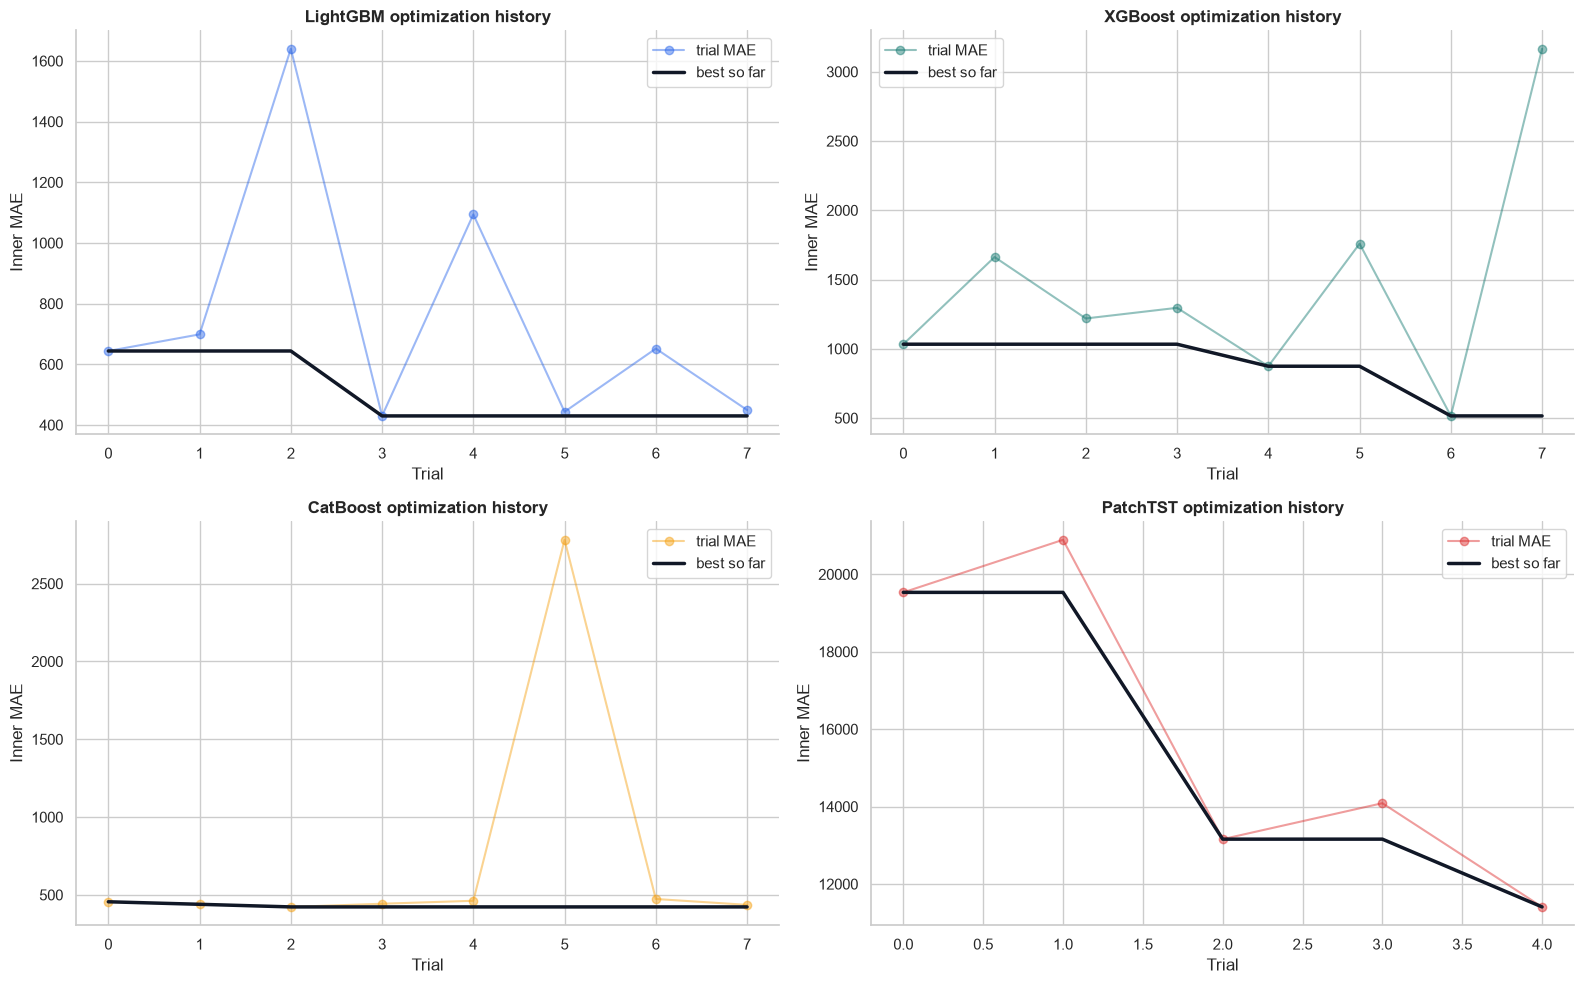

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (name, study), color in zip(axes.flat, studies.items(), COLORS):
    trials = study.trials_dataframe(attrs=("number", "value", "state"))
    trials = trials[trials.state.eq("COMPLETE")].copy()
    trials["best_so_far"] = trials.value.cummin()
    ax.plot(trials.number, trials.value, marker="o", alpha=.45, color=color, label="trial MAE")
    ax.plot(trials.number, trials.best_so_far, linewidth=2.5, color="#111827", label="best so far")
    ax.set_title(f"{name} optimization history")
    ax.set_xlabel("Trial"); ax.set_ylabel("Inner MAE"); ax.legend()
plt.tight_layout(); plt.show()

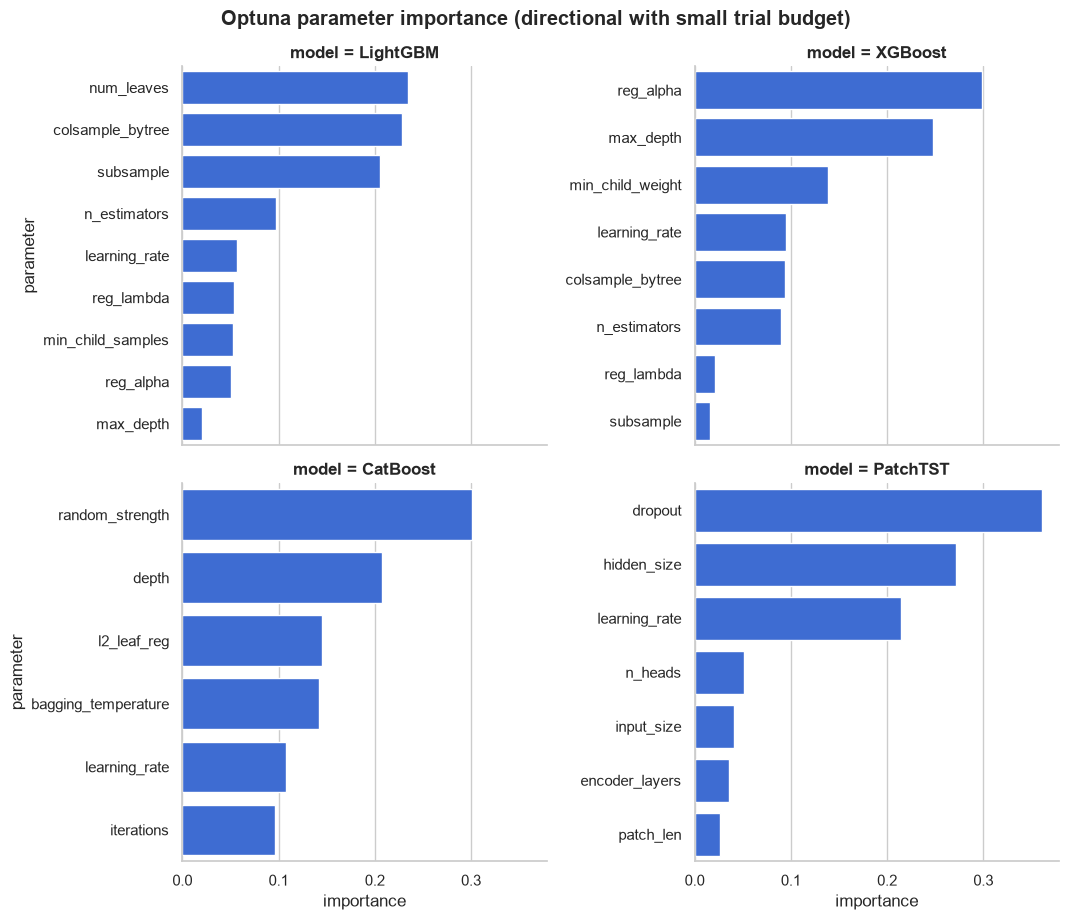

,best_inner_MAE,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda,min_child_weight,iterations,depth,l2_leaf_reg,random_strength,bagging_temperature,input_size,patch_len,encoder_layers,n_heads,hidden_size,dropout
model,,,,,,,,,,,,,,,,,,,,,,
LightGBM,429.834,304.000,0.066,17.000,8.000,18.000,0.720,0.985,3.447,1.102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
XGBoost,515.489,314.000,0.029,NaN,8.000,NaN,0.982,0.968,0.064,4.068,10.197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CatBoost,422.592,NaN,0.031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000,5.000,0.933,0.013,2.624,NaN,NaN,NaN,NaN,NaN,NaN
PatchTST,"11,408.420",NaN,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,168.000,12.000,3.000,4.000,64.000,0.011


In [13]:
importance_rows = []
for name, study in studies.items():
    try:
        importance = optuna.importance.get_param_importances(study)
        importance_rows.extend({"model": name, "parameter": k, "importance": v} for k, v in importance.items())
    except Exception as exc:
        print(f"Importance unavailable for {name}: {exc}")
tuning_importance = pd.DataFrame(importance_rows)

if not tuning_importance.empty:
    g = sea.catplot(data=tuning_importance, y="parameter", x="importance", col="model", col_wrap=2,
                    kind="bar", sharey=False, height=4.5, aspect=1.2, color=COLORS[0])
    g.fig.suptitle("Optuna parameter importance (directional with small trial budget)", y=1.02, fontweight="bold")
    plt.show()

best_params_table = pd.DataFrame([
    {"model": name, "best_inner_MAE": study.best_value, **study.best_params}
    for name, study in studies.items()
]).set_index("model")
display(best_params_table)

## 7. Learn ensemble weights from inner out-of-fold predictions

Ensemble methods are learned **only** from inner validation forecasts:

- `Mean4`: equal-weight average of the four tuned model families.
- `Median4`: robust median of the four model forecasts.
- `InverseMAE4`: weights are proportional to inverse inner MAE.
- `NNLS_All`: non-negative least-squares weights over all four models plus both baselines, normalized to sum to one.

NNLS can assign zero weight to redundant or weak members. Because it uses out-of-fold predictions rather than in-sample fitted values, it is less likely to reward overfitting.

In [14]:
best_params = {name: study.best_params for name, study in studies.items()}
inner_rows = []
inner_runtime = []

for fold, (_, test_idx) in enumerate(inner_indices, start=1):
    origin = int(test_idx[0])
    actual = values[origin: origin + HORIZON]
    common_dates = dates.iloc[origin: origin + HORIZON].to_numpy()

    # Baselines.
    for h in range(1, HORIZON + 1):
        target_idx = origin + h - 1
        common = {"fold": fold, "ds": dates.iloc[target_idx], "horizon": h, "actual": actual[h-1]}
        inner_rows.append({**common, "model": "Naive_24h", "prediction": values[target_idx - 24]})
        inner_rows.append({**common, "model": "Naive_168h", "prediction": values[target_idx - 168]})

    # Tuned tree families.
    X_train, y_train = training_cache[origin]
    X_valid = forecast_frame(values, dates, origin)
    for family in ["LightGBM", "XGBoost", "CatBoost"]:
        started = time.perf_counter()
        model = make_tree_model(family, best_params[family])
        model.fit(X_train, y_train)
        pred = np.clip(model.predict(X_valid), 0, None)
        inner_runtime.append({"model": family, "stage": "inner OOF refit", "seconds": time.perf_counter() - started})
        for h, value in enumerate(pred, start=1):
            inner_rows.append({"fold": fold, "ds": common_dates[h-1], "horizon": h,
                               "actual": actual[h-1], "model": family, "prediction": float(value)})

    # Tuned transformer, refitted with the evaluation step budget.
    started = time.perf_counter()
    train_nf = series.iloc[:origin][["unique_id", "ds", "y"]].copy()
    nf = NeuralForecast(models=[patch_model_from_params(best_params["PatchTST"], PATCH_EVAL_STEPS)], freq="h")
    nf.fit(df=train_nf, val_size=48)
    pred = np.clip(nf.predict()["PatchTST"].to_numpy()[:HORIZON], 0, None)
    inner_runtime.append({"model": "PatchTST", "stage": "inner OOF refit", "seconds": time.perf_counter() - started})
    for h, value in enumerate(pred, start=1):
        inner_rows.append({"fold": fold, "ds": common_dates[h-1], "horizon": h,
                           "actual": actual[h-1], "model": "PatchTST", "prediction": float(value)})

inner_predictions = pd.DataFrame(inner_rows)
inner_predictions["abs_error"] = (inner_predictions.actual - inner_predictions.prediction).abs()
inner_mae = inner_predictions.groupby("model").abs_error.mean().sort_values()
display(inner_mae.rename("inner_OOF_MAE").to_frame())

Seed set to 42


GPU available: False, used: False


TPU available: False, using: 0 TPU cores



  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 146 K  | train
------------------------------------------------------------------
146 K     Trainable params
3         Non-trainable params
146 K     Total params
0.584     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=200` reached.


...


  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 146 K  | train
------------------------------------------------------------------
146 K     Trainable params
3         Non-trainable params
146 K     Total params
0.584     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=200` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


,inner_OOF_MAE
model,
CatBoost,422.592
LightGBM,429.834
XGBoost,515.489
Naive_168h,554.931
PatchTST,"7,260.169"
Naive_24h,"10,825.861"


,InverseMAE4,NNLS_All
LightGBM,0.344,0.265
XGBoost,0.287,0.000
CatBoost,0.350,0.709
PatchTST,0.020,0.000
Naive_24h,0.000,0.000
Naive_168h,0.000,0.026


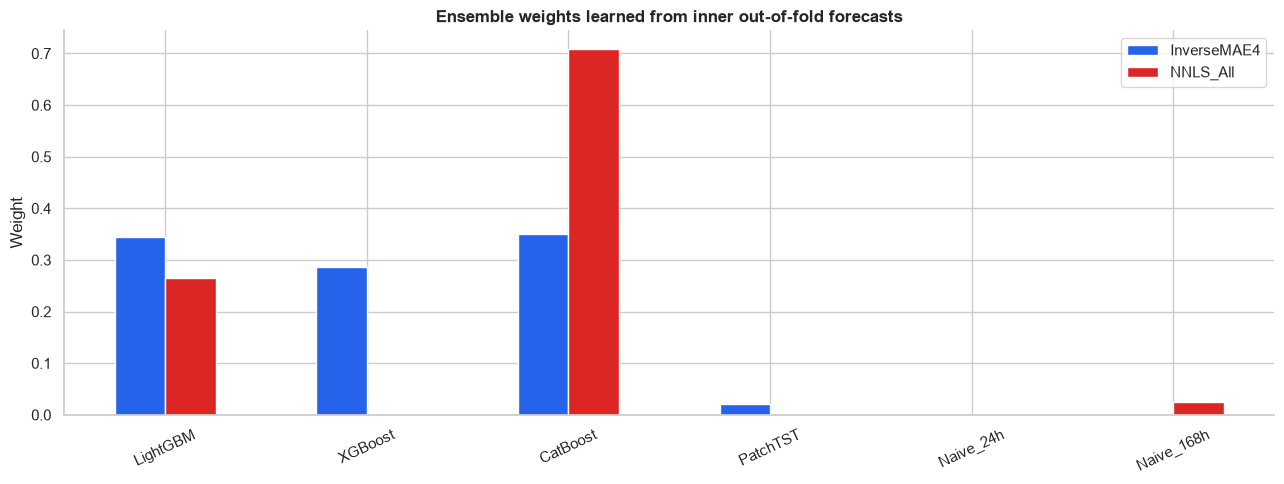

In [15]:
model_only = MODEL_FAMILIES
inverse = 1 / inner_mae.loc[model_only]
inverse_weights = inverse / inverse.sum()

inner_wide = inner_predictions.pivot_table(index=["fold", "ds", "horizon", "actual"], columns="model", values="prediction").reset_index()
nnls_candidates = MODEL_FAMILIES + BASELINES
raw_nnls_weights, _ = nnls(inner_wide[nnls_candidates].to_numpy(), inner_wide.actual.to_numpy())
if raw_nnls_weights.sum() == 0:
    raw_nnls_weights = np.ones(len(nnls_candidates))
nnls_weights = pd.Series(raw_nnls_weights / raw_nnls_weights.sum(), index=nnls_candidates, name="weight")

weight_table = pd.concat([
    inverse_weights.rename("InverseMAE4"),
    nnls_weights.rename("NNLS_All")
], axis=1).fillna(0)
display(weight_table)

weight_table.plot(kind="bar", figsize=(13, 5), color=[COLORS[0], COLORS[3]])
plt.title("Ensemble weights learned from inner out-of-fold forecasts")
plt.ylabel("Weight"); plt.xlabel(""); plt.xticks(rotation=25)
plt.tight_layout(); plt.show()

## 8. Final outer-window evaluation

Hyperparameters and ensemble weights are now frozen. Each outer fold refits the four model families using only history available at that origin and predicts the next 24 hours.

In [16]:
outer_rows = []
runtime_rows = list(tuning_times) + inner_runtime

for fold, (_, test_idx) in enumerate(outer_indices, start=1):
    origin = int(test_idx[0])
    actual = values[origin: origin + HORIZON]
    base_fold_rows = []

    # Baselines.
    for h in range(1, HORIZON + 1):
        target_idx = origin + h - 1
        common = {"fold": fold, "origin": dates.iloc[origin], "ds": dates.iloc[target_idx],
                  "horizon": h, "actual": actual[h-1]}
        base_fold_rows.append({**common, "model": "Naive_24h", "prediction": values[target_idx - 24]})
        base_fold_rows.append({**common, "model": "Naive_168h", "prediction": values[target_idx - 168]})

    # Tuned trees.
    X_train, y_train = training_cache[origin]
    X_test = forecast_frame(values, dates, origin)
    for family in ["LightGBM", "XGBoost", "CatBoost"]:
        started = time.perf_counter()
        model = make_tree_model(family, best_params[family])
        model.fit(X_train, y_train)
        pred = np.clip(model.predict(X_test), 0, None)
        runtime_rows.append({"model": family, "stage": "outer refit", "seconds": time.perf_counter() - started})
        for h, value in enumerate(pred, start=1):
            target_idx = origin + h - 1
            base_fold_rows.append({"fold": fold, "origin": dates.iloc[origin], "ds": dates.iloc[target_idx],
                                   "horizon": h, "actual": actual[h-1], "model": family, "prediction": float(value)})

    # Tuned PatchTST.
    started = time.perf_counter()
    train_nf = series.iloc[:origin][["unique_id", "ds", "y"]].copy()
    nf = NeuralForecast(models=[patch_model_from_params(best_params["PatchTST"], PATCH_EVAL_STEPS)], freq="h")
    nf.fit(df=train_nf, val_size=48)
    patch_pred = np.clip(nf.predict()["PatchTST"].to_numpy()[:HORIZON], 0, None)
    runtime_rows.append({"model": "PatchTST", "stage": "outer refit", "seconds": time.perf_counter() - started})
    for h, value in enumerate(patch_pred, start=1):
        target_idx = origin + h - 1
        base_fold_rows.append({"fold": fold, "origin": dates.iloc[origin], "ds": dates.iloc[target_idx],
                               "horizon": h, "actual": actual[h-1], "model": "PatchTST", "prediction": float(value)})

    base_fold = pd.DataFrame(base_fold_rows)
    wide = base_fold.pivot_table(index=["fold", "origin", "ds", "horizon", "actual"], columns="model", values="prediction").reset_index()
    wide["Mean4"] = wide[MODEL_FAMILIES].mean(axis=1)
    wide["Median4"] = wide[MODEL_FAMILIES].median(axis=1)
    wide["InverseMAE4"] = sum(wide[m] * inverse_weights[m] for m in MODEL_FAMILIES)
    wide["NNLS_All"] = sum(wide[m] * nnls_weights[m] for m in nnls_candidates)

    all_names = BASELINES + MODEL_FAMILIES + ["Mean4", "Median4", "InverseMAE4", "NNLS_All"]
    outer_rows.append(wide.melt(id_vars=["fold", "origin", "ds", "horizon", "actual"],
                                value_vars=all_names, var_name="model", value_name="prediction"))

predictions = pd.concat(outer_rows, ignore_index=True)
predictions["residual"] = predictions.actual - predictions.prediction
predictions["abs_error"] = predictions.residual.abs()
predictions["sq_error"] = predictions.residual ** 2
predictions["smape_component"] = 200 * predictions.abs_error / (predictions.actual.abs() + predictions.prediction.abs() + 1e-9)
print(f"Outer evaluation contains {len(predictions):,} comparable forecasts across {predictions.model.nunique()} methods.")

Seed set to 42


GPU available: False, used: False


TPU available: False, using: 0 TPU cores



  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 146 K  | train
------------------------------------------------------------------
146 K     Trainable params
3         Non-trainable params
146 K     Total params
0.584     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=200` reached.


...


  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 146 K  | train
------------------------------------------------------------------
146 K     Trainable params
3         Non-trainable params
146 K     Total params
0.584     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=200` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Outer evaluation contains 960 comparable forecasts across 10 methods.


## 9. Leaderboard and baseline assessment

- **MAE** is the primary tuning and ranking metric because it remains in operational target units.
- **RMSE** emphasizes large misses.
- **sMAPE** and **WAPE** are scale-free summaries.
- **MASE-168** scales each error by the training-set “same hour last week” error for that fold. Values below 1 indicate improvement over that in-sample seasonal scale.

Ranking by a predeclared primary metric prevents choosing whichever metric happens to flatter a preferred model.

In [17]:
fold_scales = {}
for fold, (_, test_idx) in enumerate(outer_indices, start=1):
    origin = int(test_idx[0])
    train_y = values[:origin]
    fold_scales[fold] = np.mean(np.abs(train_y[168:] - train_y[:-168]))
predictions["mase_component"] = predictions.apply(lambda r: r.abs_error / fold_scales[r.fold], axis=1)

def summarize_metrics(frame):
    return (frame.groupby("model")
            .agg(MAE=("abs_error", "mean"),
                 RMSE=("sq_error", lambda s: np.sqrt(s.mean())),
                 sMAPE_pct=("smape_component", "mean"),
                 WAPE_pct=("abs_error", lambda s: 100 * s.sum() / frame.loc[s.index, "actual"].abs().sum()),
                 MASE_168=("mase_component", "mean"),
                 Bias=("residual", "mean"), n=("actual", "size"))
            .sort_values("MAE"))

leaderboard = summarize_metrics(predictions)
baseline_mae = leaderboard.loc["Naive_168h", "MAE"]
leaderboard["MAE_improvement_vs_168h_pct"] = 100 * (baseline_mae - leaderboard.MAE) / baseline_mae
display(leaderboard.style.background_gradient(subset=["MAE", "RMSE", "sMAPE_pct", "WAPE_pct", "MASE_168"], cmap="YlGn_r").format("{:.3f}"))

,MAE,RMSE,sMAPE_pct,WAPE_pct,MASE_168,Bias,n,MAE_improvement_vs_168h_pct
model,,,,,,,,
LightGBM,514.074,844.219,0.664,0.613,0.850,39.156,96.000,26.978
Median4,520.648,868.544,0.711,0.621,0.861,98.959,96.000,26.044
NNLS_All,523.707,874.184,0.668,0.625,0.866,39.264,96.000,25.610
CatBoost,537.540,896.914,0.683,0.641,0.888,35.198,96.000,23.645
InverseMAE4,544.546,855.927,0.852,0.649,0.900,79.713,96.000,22.650
XGBoost,626.229,1012.397,0.976,0.747,1.036,214.221,96.000,11.047
Naive_168h,704.000,1126.181,0.937,0.840,1.164,153.688,96.000,0.000
Mean4,1895.615,2264.828,4.806,2.261,3.133,-19.084,96.000,-169.264
PatchTST,7161.437,8846.501,19.214,8.540,11.838,-364.911,96.000,-917.250


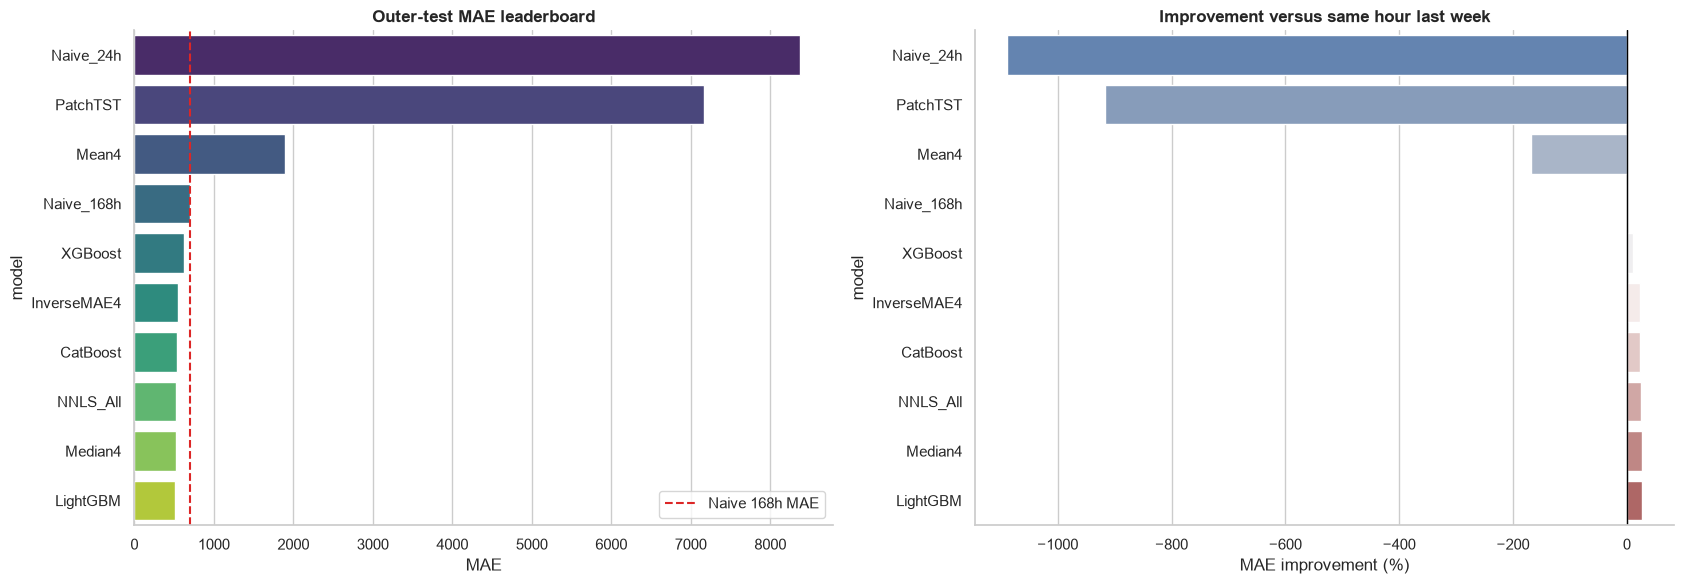

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
rank_plot = leaderboard.reset_index().sort_values("MAE", ascending=False)
sea.barplot(data=rank_plot, y="model", x="MAE", ax=axes[0], palette="viridis")
axes[0].axvline(baseline_mae, color=COLORS[3], linestyle="--", label="Naive 168h MAE")
axes[0].set_title("Outer-test MAE leaderboard"); axes[0].legend()
sea.barplot(data=rank_plot, y="model", x="MAE_improvement_vs_168h_pct", ax=axes[1], palette="vlag")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Improvement versus same hour last week")
axes[1].set_xlabel("MAE improvement (%)")
plt.tight_layout(); plt.show()

## 10. Performance by horizon and fold

Aggregate scores can hide where a method fails. Horizon curves show error accumulation from 1 to 24 hours. Fold heatmaps show whether performance is stable across different days.

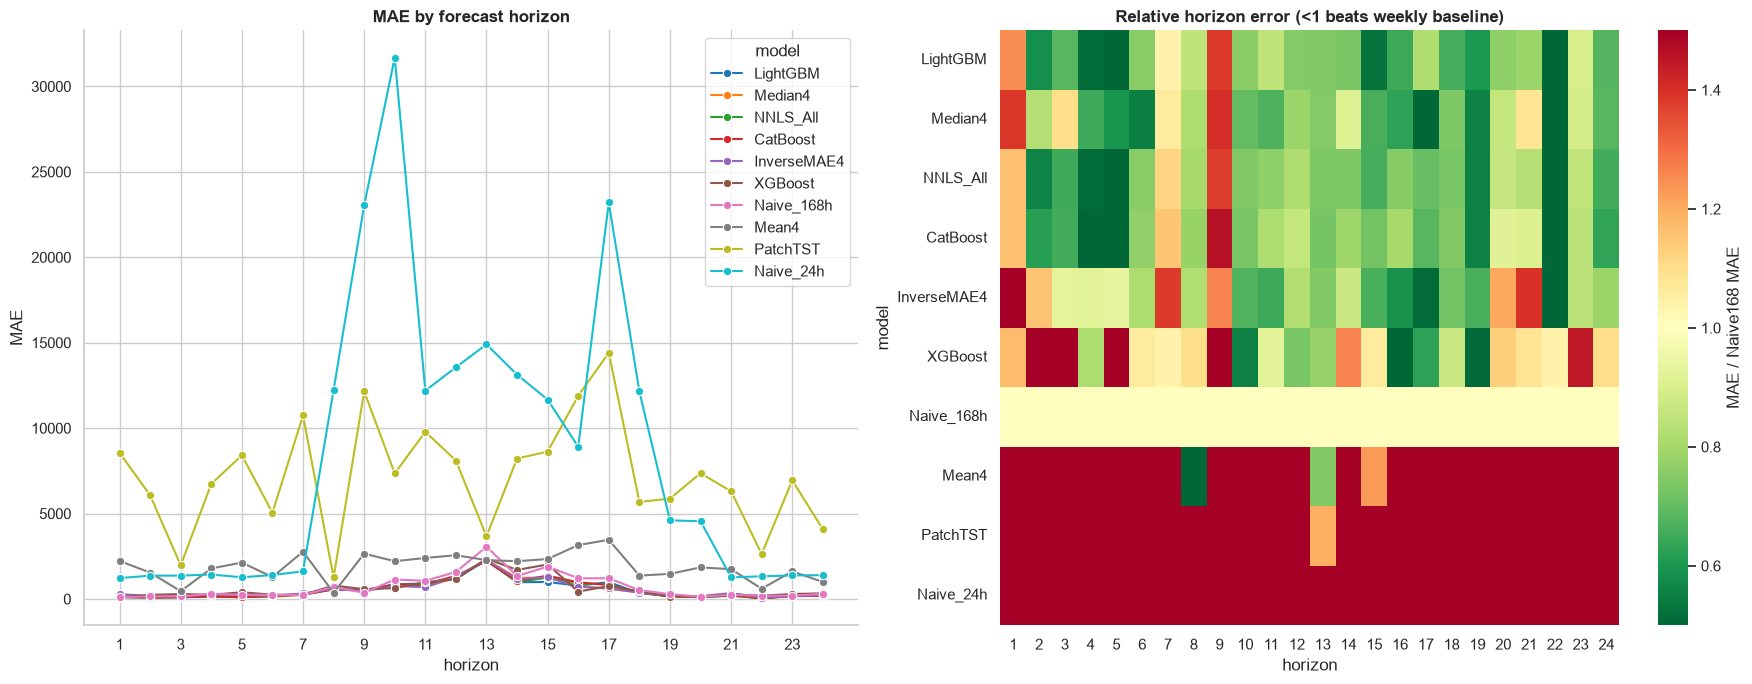

In [19]:
horizon_mae = predictions.groupby(["model", "horizon"]).abs_error.mean().reset_index(name="MAE")
selected_order = leaderboard.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sea.lineplot(data=horizon_mae, x="horizon", y="MAE", hue="model", hue_order=selected_order,
             marker="o", palette="tab10", ax=axes[0])
axes[0].set_title("MAE by forecast horizon"); axes[0].set_xticks(range(1, 25, 2))

baseline_curve = horizon_mae.query("model == 'Naive_168h'").set_index("horizon").MAE
ratio = horizon_mae.pivot(index="model", columns="horizon", values="MAE").div(baseline_curve, axis=1)
ratio = ratio.reindex(selected_order)
sea.heatmap(ratio, cmap="RdYlGn_r", center=1, vmin=.5, vmax=1.5, ax=axes[1], cbar_kws={"label": "MAE / Naive168 MAE"})
axes[1].set_title("Relative horizon error (<1 beats weekly baseline)")
plt.tight_layout(); plt.show()

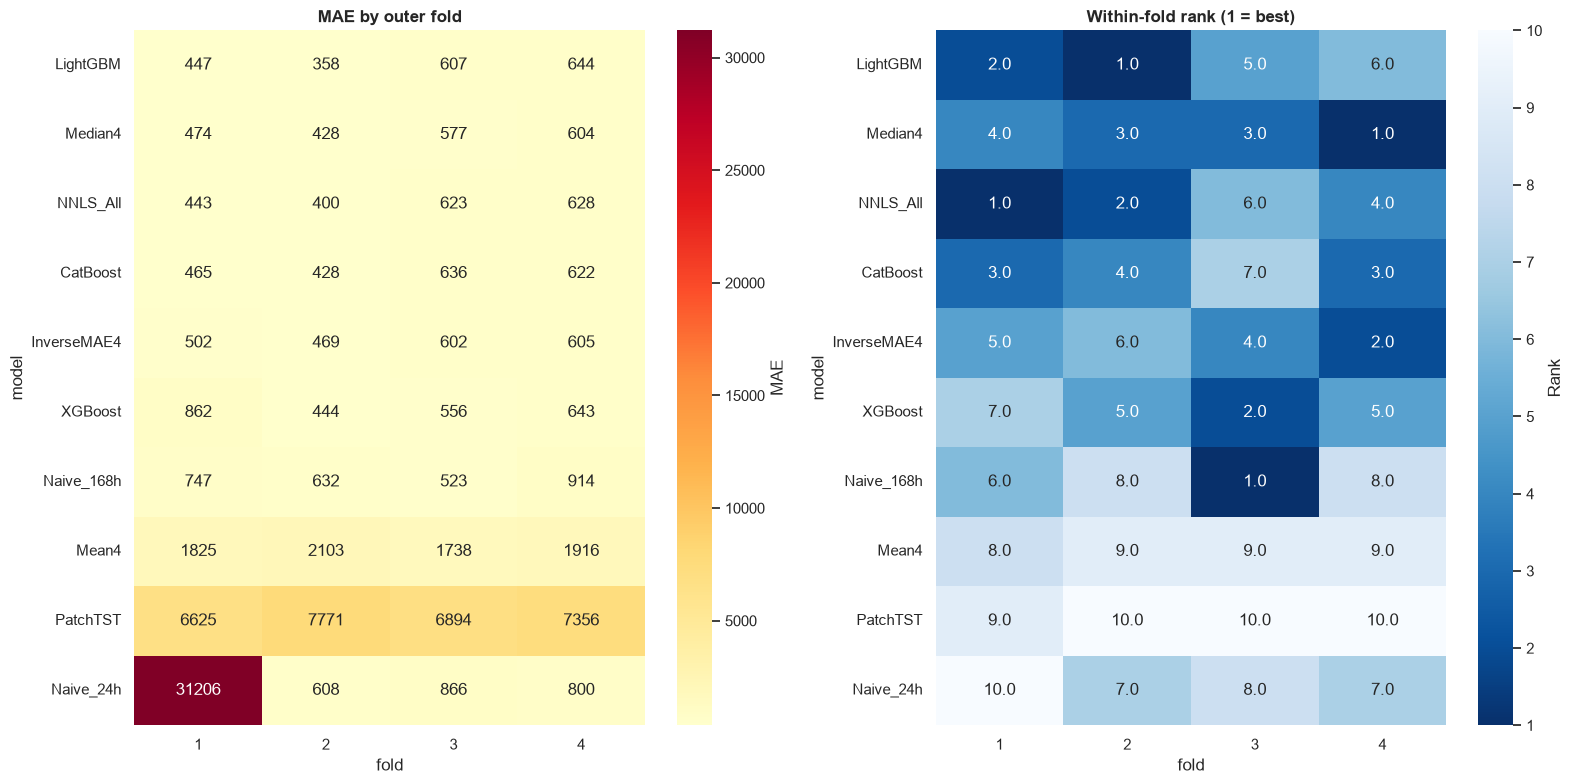

,mean_rank,rank_std
model,,
Median4,2.750,1.258
NNLS_All,3.250,2.217
LightGBM,3.500,2.380
CatBoost,4.250,1.893
InverseMAE4,4.250,1.708
XGBoost,4.750,2.062
Naive_168h,5.750,3.304
Naive_24h,8.000,1.414
Mean4,8.750,0.500


In [20]:
fold_mae = predictions.groupby(["model", "fold"]).abs_error.mean().unstack()
fold_mae = fold_mae.loc[selected_order]
fold_ranks = fold_mae.rank(axis=0, method="average")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sea.heatmap(fold_mae, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[0], cbar_kws={"label": "MAE"})
axes[0].set_title("MAE by outer fold")
sea.heatmap(fold_ranks, annot=True, fmt=".1f", cmap="Blues_r", ax=axes[1], cbar_kws={"label": "Rank"})
axes[1].set_title("Within-fold rank (1 = best)")
plt.tight_layout(); plt.show()

rank_stability = pd.DataFrame({"mean_rank": fold_ranks.mean(axis=1), "rank_std": fold_ranks.std(axis=1)}).sort_values("mean_rank")
display(rank_stability)

## 11. Residual diagnostics, bias, and traffic regimes

A trustworthy model should not only have a low average error. Residuals should be centered near zero, avoid strong temporal structure, and remain acceptable during both quiet and peak-demand periods.

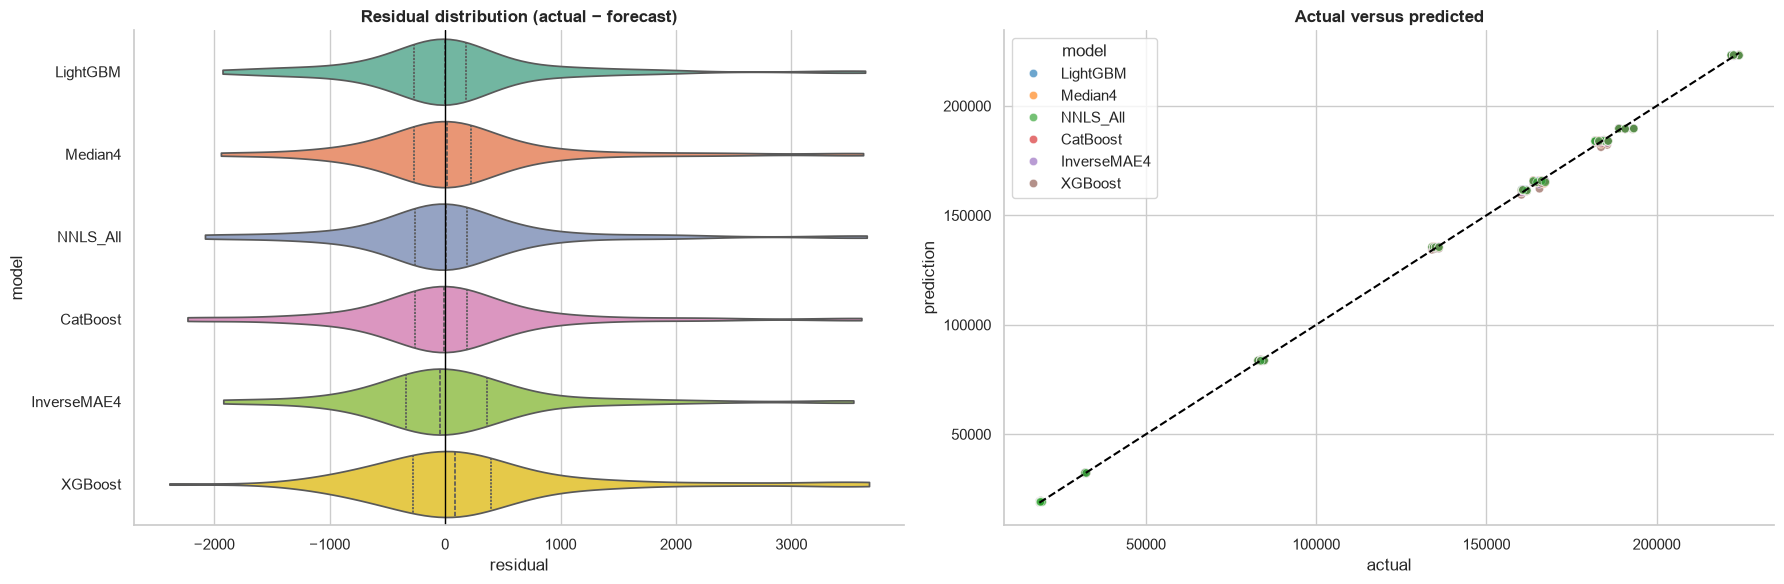

In [21]:
top_methods = leaderboard.head(6).index.tolist()
diag = predictions[predictions.model.isin(top_methods)].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sea.violinplot(data=diag, y="model", x="residual", order=top_methods, inner="quartile", cut=0, palette="Set2", ax=axes[0])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Residual distribution (actual − forecast)")
sea.scatterplot(data=diag, x="actual", y="prediction", hue="model", hue_order=top_methods, alpha=.65, ax=axes[1], palette="tab10")
lo, hi = diag.actual.min(), diag.actual.max()
axes[1].plot([lo, hi], [lo, hi], color="black", linestyle="--")
axes[1].set_title("Actual versus predicted")
plt.tight_layout(); plt.show()

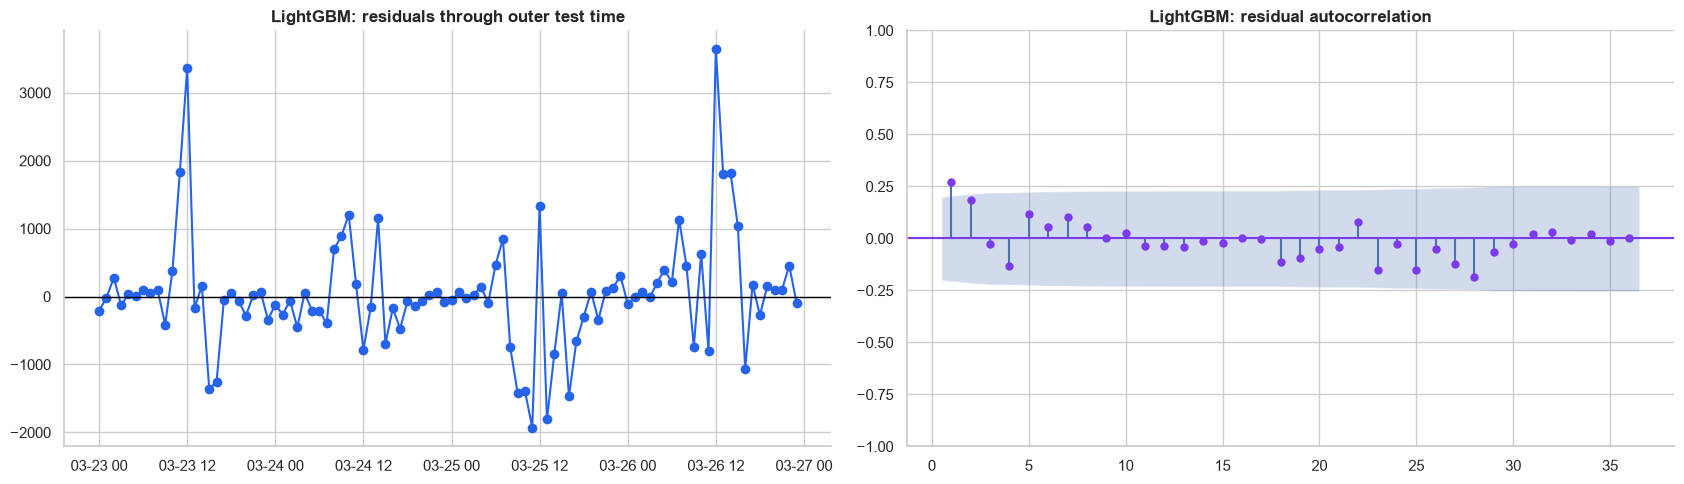

In [22]:
best_method = leaderboard.index[0]
best_residuals = predictions.query("model == @best_method").sort_values("ds")
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
axes[0].plot(best_residuals.ds, best_residuals.residual, marker="o", color=COLORS[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title(f"{best_method}: residuals through outer test time")
plot_acf(best_residuals.residual, lags=36, zero=False, ax=axes[1], color=COLORS[4])
axes[1].set_title(f"{best_method}: residual autocorrelation")
plt.tight_layout(); plt.show()

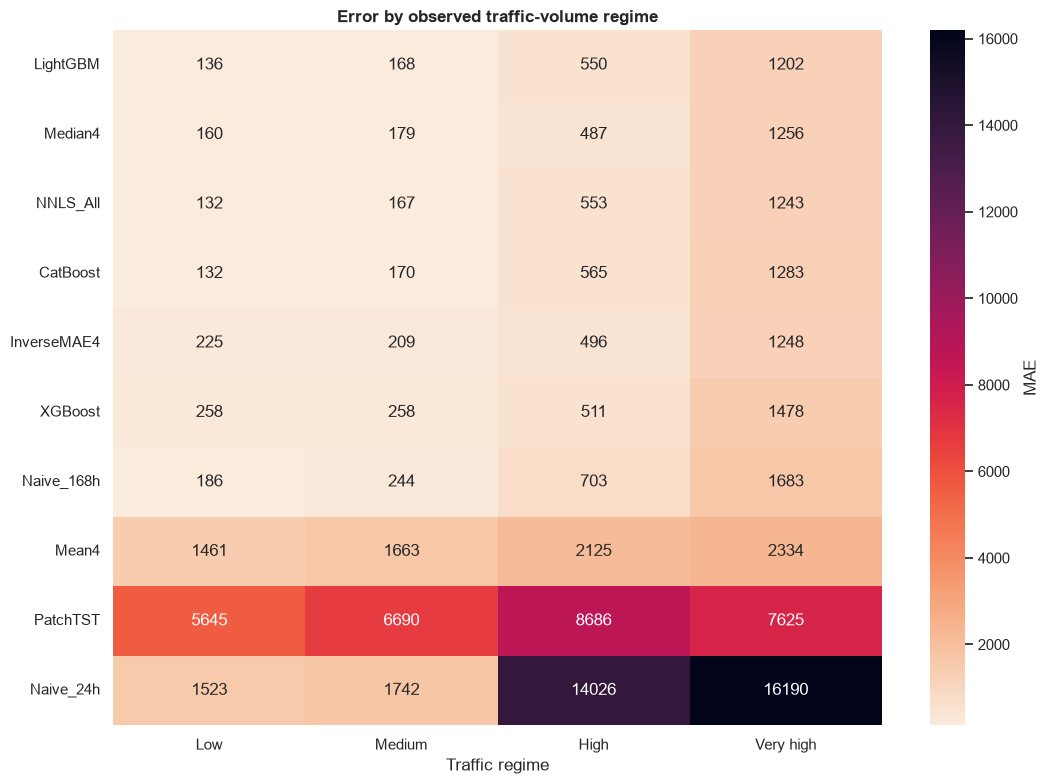

In [23]:
# Regime bands are based only on the evaluated actual values and used for diagnosis, not as features.
unique_actual = predictions.drop_duplicates(["fold", "ds"])[["fold", "ds", "actual"]].copy()
unique_actual["traffic_regime"] = pd.qcut(unique_actual.actual, q=4, labels=["Low", "Medium", "High", "Very high"], duplicates="drop")
regime_predictions = predictions.merge(unique_actual[["fold", "ds", "traffic_regime"]], on=["fold", "ds"], how="left")
regime_mae = regime_predictions.groupby(["model", "traffic_regime"], observed=True).abs_error.mean().unstack()
regime_mae = regime_mae.loc[selected_order]

plt.figure(figsize=(11, 8))
sea.heatmap(regime_mae, annot=True, fmt=".0f", cmap="rocket_r", cbar_kws={"label": "MAE"})
plt.title("Error by observed traffic-volume regime")
plt.xlabel("Traffic regime"); plt.ylabel("")
plt.tight_layout(); plt.show()

## 12. Forecast disagreement as a practical uncertainty signal

The range across four structurally different tuned models is not a formal prediction interval. It is still useful as a **model-disagreement indicator**: large spread identifies hours where planning should be more conservative or where a human review may be warranted.

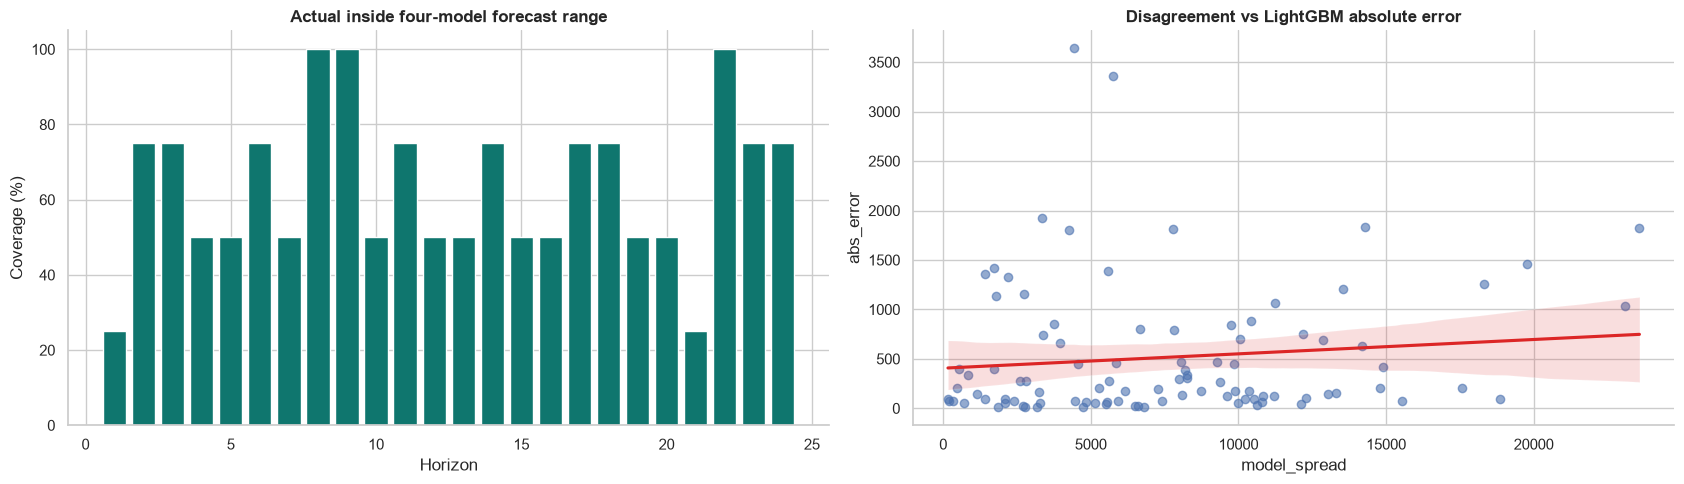

In [24]:
base_wide = (predictions[predictions.model.isin(MODEL_FAMILIES)]
             .pivot_table(index=["fold", "ds", "horizon", "actual"], columns="model", values="prediction")
             .reset_index())
base_wide["forecast_min"] = base_wide[MODEL_FAMILIES].min(axis=1)
base_wide["forecast_max"] = base_wide[MODEL_FAMILIES].max(axis=1)
base_wide["model_spread"] = base_wide.forecast_max - base_wide.forecast_min
base_wide["covered_by_model_range"] = base_wide.actual.between(base_wide.forecast_min, base_wide.forecast_max)
recommended_errors = predictions.query("model == @best_method")[["fold", "ds", "abs_error"]]
base_wide = base_wide.merge(recommended_errors, on=["fold", "ds"], how="left")

coverage_by_h = base_wide.groupby("horizon").covered_by_model_range.mean().mul(100)
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
axes[0].bar(coverage_by_h.index, coverage_by_h.values, color=COLORS[1])
axes[0].set_title("Actual inside four-model forecast range")
axes[0].set_ylabel("Coverage (%)"); axes[0].set_xlabel("Horizon")
sea.regplot(data=base_wide, x="model_spread", y="abs_error", scatter_kws={"alpha": .6}, line_kws={"color": COLORS[3]}, ax=axes[1])
axes[1].set_title(f"Disagreement vs {best_method} absolute error")
plt.tight_layout(); plt.show()

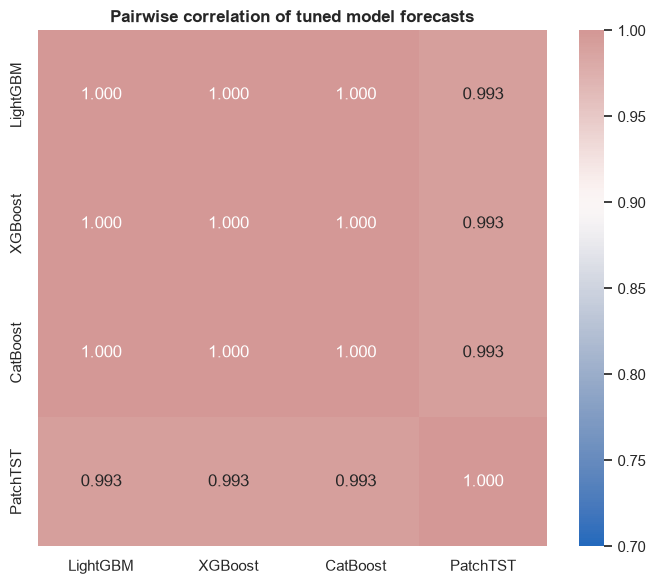

In [25]:
forecast_corr = base_wide[MODEL_FAMILIES].corr()
plt.figure(figsize=(7, 6))
sea.heatmap(forecast_corr, annot=True, fmt=".3f", cmap="vlag", center=.9, vmin=.7, vmax=1)
plt.title("Pairwise correlation of tuned model forecasts")
plt.tight_layout(); plt.show()

## 13. Accuracy–runtime trade-off

Runtime is environment-dependent, but it helps determine whether a marginal accuracy gain justifies repeated tuning and refitting. The plot separates tuning cost from average outer-refit cost.

,model,stage,mean,sum,count
0,CatBoost,Optuna tuning,55.426,55.426,1
1,CatBoost,inner OOF refit,2.178,6.535,3
2,CatBoost,outer refit,2.296,9.183,4
3,LightGBM,Optuna tuning,18.939,18.939,1
4,LightGBM,inner OOF refit,0.661,1.983,3
5,LightGBM,outer refit,0.707,2.827,4
6,PatchTST,Optuna tuning,8.864,8.864,1
7,PatchTST,inner OOF refit,3.290,9.870,3
8,PatchTST,outer refit,3.405,13.618,4
9,XGBoost,Optuna tuning,22.007,22.007,1


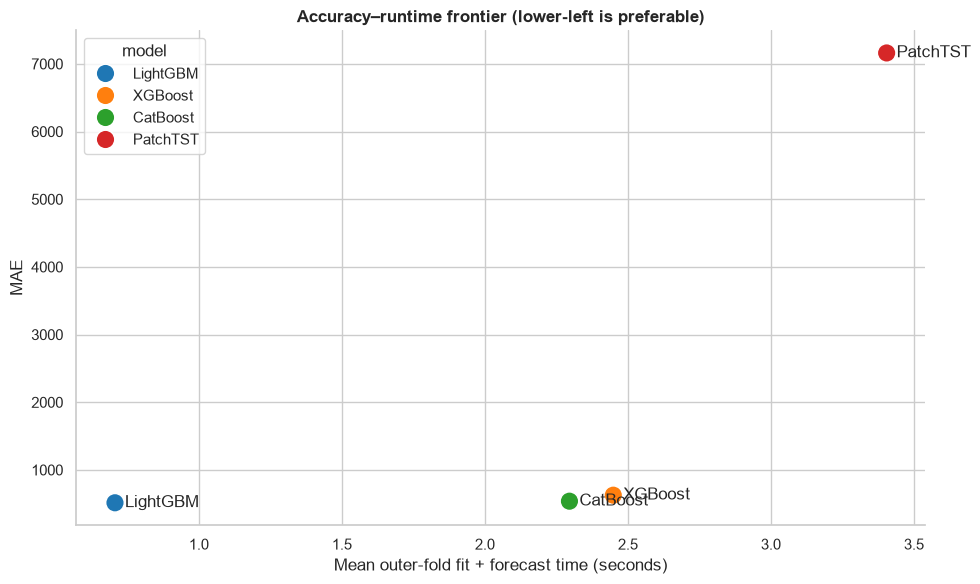

In [26]:
runtime = pd.DataFrame(runtime_rows)
runtime_summary = (runtime.groupby(["model", "stage"]).seconds.agg(["mean", "sum", "count"]).reset_index())
display(runtime_summary)

outer_runtime = (runtime.query("stage == 'outer refit'").groupby("model").seconds.mean().rename("mean_outer_refit_seconds"))
efficiency = leaderboard.loc[MODEL_FAMILIES, ["MAE"]].join(outer_runtime).reset_index()
plt.figure(figsize=(10, 6))
sea.scatterplot(data=efficiency, x="mean_outer_refit_seconds", y="MAE", hue="model", s=180, palette="tab10")
for row in efficiency.itertuples():
    plt.text(row.mean_outer_refit_seconds, row.MAE, f"  {row.model}", va="center")
plt.title("Accuracy–runtime frontier (lower-left is preferable)")
plt.xlabel("Mean outer-fold fit + forecast time (seconds)")
plt.tight_layout(); plt.show()

## 14. Tree feature importance

Each tree family is refitted on all available data. Native feature importance measures differ by implementation, so compare rankings within a model rather than treating magnitudes as directly comparable across libraries.

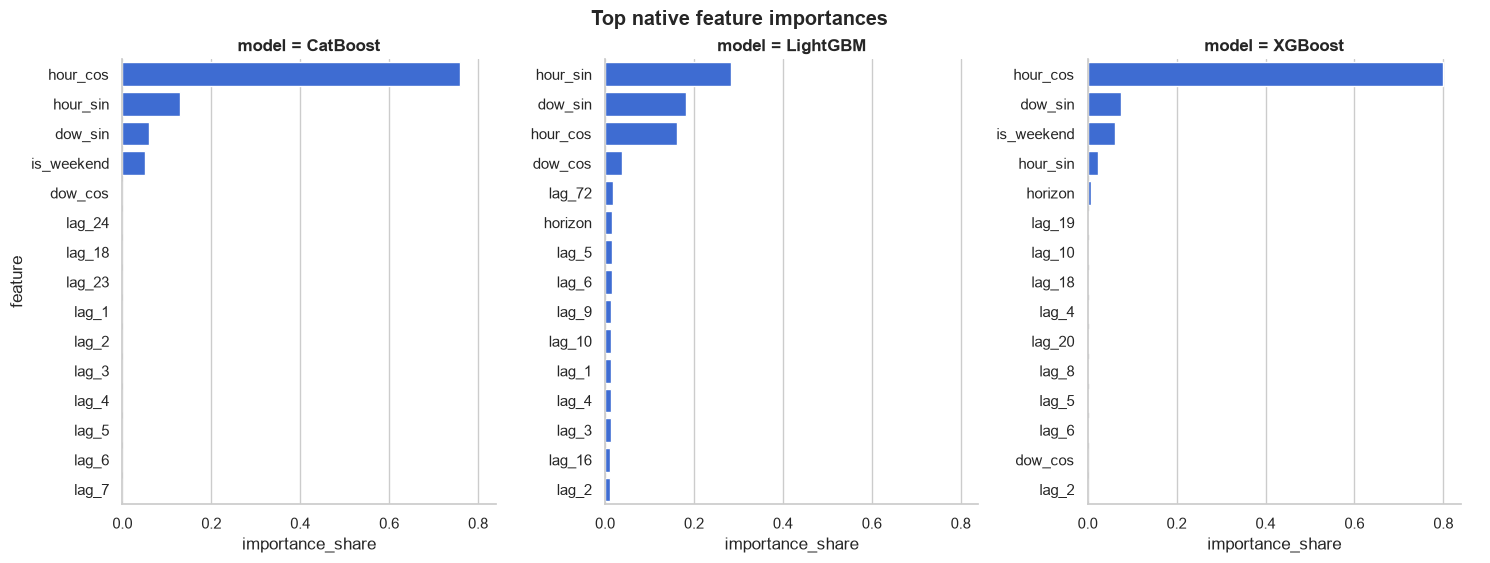

In [27]:
full_dates = pd.concat([dates, pd.Series(pd.date_range(dates.iloc[-1] + pd.Timedelta(hours=1), periods=HORIZON, freq="h"))], ignore_index=True)
full_X, full_y = stacked_training_frame(values, full_dates, len(series))
final_models = {}
final_runtime = []
importance_frames = []

for family in ["LightGBM", "XGBoost", "CatBoost"]:
    started = time.perf_counter()
    model = make_tree_model(family, best_params[family])
    model.fit(full_X, full_y)
    final_models[family] = model
    final_runtime.append({"model": family, "seconds": time.perf_counter() - started})
    importance_frames.append(pd.DataFrame({
        "model": family, "feature": full_X.columns, "importance": model.feature_importances_
    }))

feature_importance = pd.concat(importance_frames, ignore_index=True)
feature_importance["importance_share"] = feature_importance.groupby("model").importance.transform(lambda x: x / x.sum())
top_importance = (feature_importance.sort_values(["model", "importance_share"], ascending=[True, False])
                  .groupby("model").head(15))

g = sea.catplot(data=top_importance, y="feature", x="importance_share", col="model", kind="bar",
                sharey=False, height=5.5, aspect=.9, color=COLORS[0])
g.fig.suptitle("Top native feature importances", y=1.02, fontweight="bold")
plt.show()

## 15. Final refit and next-24-hour forecast

The next block uses every available observation. It retains all individual forecasts and all ensemble variants. `RecommendedForecast` copies the method with the best frozen outer-test MAE; this lets a baseline win if complexity did not earn an improvement.

In [28]:
future_dates = pd.date_range(dates.iloc[-1] + pd.Timedelta(hours=1), periods=HORIZON, freq="h")
X_future = forecast_frame(values, full_dates, len(series))
future_table = pd.DataFrame({"ds": future_dates, "horizon": range(1, HORIZON + 1)})

# Seasonal baselines.
for name, lag in [("Naive_24h", 24), ("Naive_168h", 168)]:
    future_table[name] = [values[len(series) + h - 1 - lag] for h in range(1, HORIZON + 1)]

# Already-refitted tree models.
for family, model in final_models.items():
    future_table[family] = np.clip(model.predict(X_future), 0, None)

# Tuned PatchTST final refit.
started = time.perf_counter()
final_nf = NeuralForecast(models=[patch_model_from_params(best_params["PatchTST"], PATCH_EVAL_STEPS)], freq="h")
final_nf.fit(df=series[["unique_id", "ds", "y"]], val_size=48)
future_table["PatchTST"] = np.clip(final_nf.predict()["PatchTST"].to_numpy()[:HORIZON], 0, None)
final_runtime.append({"model": "PatchTST", "seconds": time.perf_counter() - started})

# Frozen ensemble rules learned before outer evaluation.
future_table["Mean4"] = future_table[MODEL_FAMILIES].mean(axis=1)
future_table["Median4"] = future_table[MODEL_FAMILIES].median(axis=1)
future_table["InverseMAE4"] = sum(future_table[m] * inverse_weights[m] for m in MODEL_FAMILIES)
future_table["NNLS_All"] = sum(future_table[m] * nnls_weights[m] for m in nnls_candidates)
future_table["RecommendedForecast"] = future_table[best_method]
display(future_table)

Seed set to 42


GPU available: False, used: False


TPU available: False, using: 0 TPU cores



  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 146 K  | train
------------------------------------------------------------------
146 K     Trainable params
3         Non-trainable params
146 K     Total params
0.584     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=200` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


,ds,horizon,Naive_24h,Naive_168h,LightGBM,XGBoost,CatBoost,PatchTST,Mean4,Median4,InverseMAE4,NNLS_All,RecommendedForecast
0,2026-03-27 00:00:00,1,"18,923.000","19,141.000","19,089.998","19,047.762","19,082.240","13,180.834","17,600.208","19,065.001","18,954.969","19,085.351","19,089.998"
1,2026-03-27 01:00:00,2,"19,107.000","19,380.000","19,108.563","19,185.113","19,098.920","22,180.031","19,893.157","19,146.838","19,189.612","19,108.944","19,108.563"
2,2026-03-27 02:00:00,3,"19,167.000","19,043.000","19,069.266","19,292.709","19,098.864","20,156.648","19,404.372","19,195.786","19,165.754","19,089.662","19,069.266"
3,2026-03-27 03:00:00,4,"19,081.000","18,919.000","19,044.973","18,960.564","19,038.881","24,747.969","20,448.097","19,041.927","19,134.680","19,037.855","19,044.973"
4,2026-03-27 04:00:00,5,"19,265.000","18,956.000","19,051.775","18,781.521","19,060.357","27,950.811","21,211.116","19,056.066","19,158.381","19,056.086","19,051.775"
5,2026-03-27 05:00:00,6,"19,502.000","19,127.000","19,043.161","19,032.010","19,056.650","24,727.607","20,464.857","19,049.906","19,160.324","19,055.323","19,043.161"
6,2026-03-27 06:00:00,7,"19,264.000","18,875.000","18,987.969","19,086.023","19,056.484","21,779.438","19,727.479","19,071.254","19,096.800","19,033.864","18,987.969"
7,2026-03-27 07:00:00,8,"84,717.000","83,228.000","83,697.172","83,571.516","83,867.235","78,012.812","82,287.184","83,634.344","83,604.965","83,805.256","83,697.172"
8,2026-03-27 08:00:00,9,"161,890.000","160,619.000","161,419.640","161,169.688","161,428.225","153,235.547","159,313.275","161,294.664","161,184.528","161,404.502","161,419.640"
9,2026-03-27 09:00:00,10,"222,629.000","222,459.000","223,187.427","222,777.250","221,570.842","208,433.641","218,992.290","222,174.046","222,204.739","222,021.232","223,187.427"


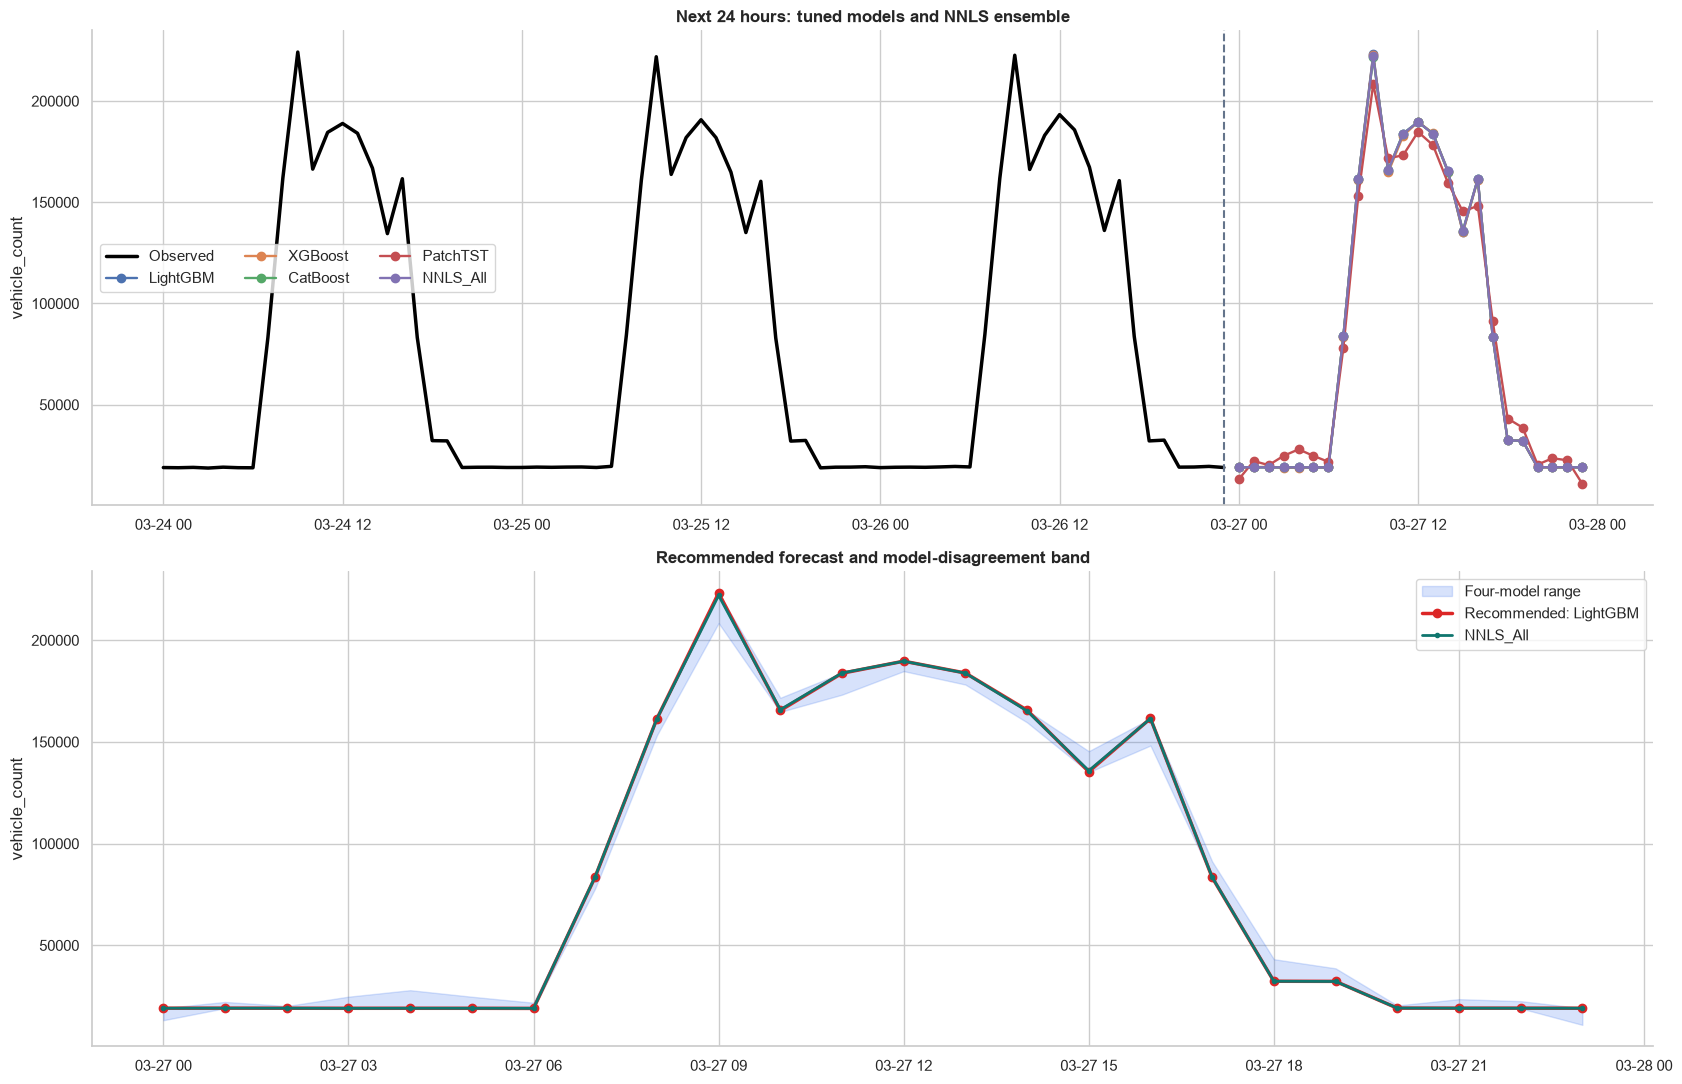

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(17, 11), sharex=False)
history = series.tail(72)
axes[0].plot(history.ds, history.y, color="black", linewidth=2.5, label="Observed")
for name in MODEL_FAMILIES + ["NNLS_All"]:
    axes[0].plot(future_table.ds, future_table[name], marker="o", linewidth=1.7, label=name)
axes[0].axvline(series.ds.iloc[-1], color=COLORS[6], linestyle="--")
axes[0].set_title(f"Next 24 hours: tuned models and NNLS ensemble")
axes[0].set_ylabel(TARGET); axes[0].legend(ncol=3)

model_min = future_table[MODEL_FAMILIES].min(axis=1)
model_max = future_table[MODEL_FAMILIES].max(axis=1)
axes[1].fill_between(future_table.ds, model_min, model_max, color=COLORS[0], alpha=.18, label="Four-model range")
axes[1].plot(future_table.ds, future_table.RecommendedForecast, color=COLORS[3], marker="o", linewidth=2.5, label=f"Recommended: {best_method}")
axes[1].plot(future_table.ds, future_table.NNLS_All, color=COLORS[1], marker=".", linewidth=2, label="NNLS_All")
axes[1].set_title("Recommended forecast and model-disagreement band")
axes[1].set_ylabel(TARGET); axes[1].legend()
plt.tight_layout(); plt.show()

## 16. Data-driven conclusion

The narrative below is generated from the executed results, so it stays synchronized with the table rather than asserting in advance that a complex model must win.

In [30]:
best_mae = leaderboard.iloc[0].MAE
best_improvement = leaderboard.iloc[0].MAE_improvement_vs_168h_pct
best_family = leaderboard.loc[MODEL_FAMILIES].MAE.idxmin()
best_family_mae = leaderboard.loc[best_family, "MAE"]
best_ensemble = leaderboard.loc[["Mean4", "Median4", "InverseMAE4", "NNLS_All"]].MAE.idxmin()
best_ensemble_mae = leaderboard.loc[best_ensemble, "MAE"]
patch_rank = int(leaderboard.MAE.rank(method="min")["PatchTST"])

display(Markdown(f'''
### Executive interpretation

- **Recommended method:** `{best_method}` achieved the lowest untouched outer-test MAE at **{best_mae:,.1f}**.
- **Baseline comparison:** its MAE improvement versus the 168-hour seasonal naïve baseline was **{best_improvement:+.1f}%**.
- **Best individual boosted-tree family:** `{best_family}` with MAE **{best_family_mae:,.1f}**.
- **Best ensemble:** `{best_ensemble}` with MAE **{best_ensemble_mae:,.1f}**. Ensembling helped only if this score is below its strongest constituent and the weekly baseline.
- **PatchTST result:** it ranked **{patch_rank} of {len(leaderboard)}** methods by MAE under the stated search/training budget. This is an empirical result for this short simulated series—not a general verdict on transformers.
- **Operational use:** adopt `RecommendedForecast` for the point estimate and use the four-model range as an escalation signal, not as a statistically calibrated prediction interval.
'''))


### Executive interpretation

- **Recommended method:** `LightGBM` achieved the lowest untouched outer-test MAE at **514.1**.
- **Baseline comparison:** its MAE improvement versus the 168-hour seasonal naïve baseline was **+27.0%**.
- **Best individual boosted-tree family:** `LightGBM` with MAE **514.1**.
- **Best ensemble:** `Median4` with MAE **520.6**. Ensembling helped only if this score is below its strongest constituent and the weekly baseline.
- **PatchTST result:** it ranked **9 of 10** methods by MAE under the stated search/training budget. This is an empirical result for this short simulated series—not a general verdict on transformers.
- **Operational use:** adopt `RecommendedForecast` for the point estimate and use the four-model range as an escalation signal, not as a statistically calibrated prediction interval.


## 17. Limitations and production checklist

**Limitations**

- Only four outer days are evaluated; metric uncertainty is therefore material.
- Optuna budgets are intentionally modest for notebook reproducibility.
- Hyperparameters are tuned once before the entire outer block rather than retuned inside every outer fold.
- The model-disagreement band is not a formal probabilistic interval.
- The series is a citywide aggregate; local congestion may be hidden by network totals.
- The dataset is simulated and cleaner than live IoT feeds.

**Before production**

1. Expand outer evaluation to multiple months and seasons with daily or weekly origins.
2. Increase Optuna budgets and use pruning/early stopping while preserving nested temporal validation.
3. Add scheduled events, planned construction, and weather forecasts only when those values are truly known at forecast time.
4. Forecast zones/intersections and reconcile them to the citywide total.
5. Calibrate prediction intervals with rolling conformal methods and report empirical coverage.
6. Test daylight-saving transitions, duplicates, delayed sensors, missing hours, and schema changes.
7. Monitor performance by horizon, traffic regime, day type, and model-disagreement level after deployment.